In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("cleaned_reproducible_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_reproducible_dataset.csv'

In [ ]:
print("===== MISSING VALUE CHECK =====")

missing = df.isnull().sum().sort_values(ascending=False)

print(missing[missing > 0])

print("\nTotal missing values:", df.isnull().sum().sum())

===== MISSING VALUE CHECK =====
Illness       47
Occupation    23
Age            7
dtype: int64

Total missing values: 77


In [ ]:
from google.colab import files

uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv("model_ready_reproducible_dataset.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1120, 82)


In [ ]:
print("\n===== COLUMNS =====")
for i, col in enumerate(df.columns, 1):
    print(i, ":", col)


===== COLUMNS =====
1 : Age_Group__15-24
2 : Age_Group__25-34
3 : Age_Group__35-44
4 : Age_Group__45-54
5 : Age_Group__55-64
6 : Age_Group__65-74
7 : Age_Group__75-84
8 : Age_Group__85-94
9 : Age_Group__95+
10 : Age_Group__<15
11 : Age_Group__Unknown/Not reported
12 : Gender__Female
13 : Gender__Male
14 : Religion__Buddhist
15 : Religion__Christian
16 : Religion__Hindu
17 : Religion__Islam
18 : Religion__Other
19 : Occupation_Standard__Administrative Executive Managerial & related workers
20 : Occupation_Standard__Agricultural Animal Husbandry Fisherman & related Forestry workers
21 : Occupation_Standard__Armed Services
22 : Occupation_Standard__Clerical & related workers (Stenographers/ Typists etc)
23 : Occupation_Standard__Housewife
24 : Occupation_Standard__Other
25 : Occupation_Standard__Pensioners
26 : Occupation_Standard__Police
27 : Occupation_Standard__Production process workers Craftsman & related workers transport equipment operators & labourers
28 : Occupation_Standard__Pr

In [ ]:
print("\n===== MISSING VALUE CHECK =====")

missing = df.isnull().sum()

print("Total missing values:", missing.sum())

if missing.sum() == 0:
    print("✅ No missing values found.")
else:
    print("\nColumns with missing values:")
    print(missing[missing > 0])


===== MISSING VALUE CHECK =====
Total missing values: 0
✅ No missing values found.


In [ ]:
print("\n===== DUPLICATE CHECK =====")

duplicates = df.duplicated().sum()

print("Duplicate rows:", duplicates)

if duplicates == 0:
    print("✅ No duplicate rows found.")


===== DUPLICATE CHECK =====
Duplicate rows: 26


In [ ]:
print("Shape:", df.shape)

print("\nDuplicate rows:", df.duplicated().sum())

print("\nFirst 10 duplicated rows:")
display(df[df.duplicated(keep=False)].sort_values(
    by="Attempted?"
).head(10))

Shape: (1120, 82)

Duplicate rows: 26

First 10 duplicated rows:


,Age_Group__15-24,Age_Group__25-34,Age_Group__35-44,Age_Group__45-54,Age_Group__55-64,Age_Group__65-74,Age_Group__75-84,Age_Group__85-94,Age_Group__95+,Age_Group__<15,...,Sleep Problem__Yes,Isolation__No,Isolation__Not sure,Isolation__Yes,Humiliated__No,Humiliated__Yes,Sad/ Weary__0.0,Sad/ Weary__1.0,Sad/ Weary__Unknown/Not reported,Attempted?
697,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,1,0,1,0,0,0
682,0,0,0,0,1,0,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
587,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
570,0,0,0,1,0,0,0,0,0,0,...,1,1,0,0,1,0,1,0,0,0
763,0,0,0,0,0,0,0,1,0,0,...,0,1,0,0,1,0,1,0,0,0
707,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
701,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
700,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
764,1,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,1,0,0,0
776,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,1,0,1,0,0,0


In [ ]:
print("\nColumns:")
print(df.columns.tolist())


Columns:
['Age_Group__15-24', 'Age_Group__25-34', 'Age_Group__35-44', 'Age_Group__45-54', 'Age_Group__55-64', 'Age_Group__65-74', 'Age_Group__75-84', 'Age_Group__85-94', 'Age_Group__95+', 'Age_Group__<15', 'Age_Group__Unknown/Not reported', 'Gender__Female', 'Gender__Male', 'Religion__Buddhist', 'Religion__Christian', 'Religion__Hindu', 'Religion__Islam', 'Religion__Other', 'Occupation_Standard__Administrative Executive Managerial & related workers', 'Occupation_Standard__Agricultural Animal Husbandry Fisherman & related Forestry workers', 'Occupation_Standard__Armed Services', 'Occupation_Standard__Clerical & related workers (Stenographers/ Typists etc)', 'Occupation_Standard__Housewife', 'Occupation_Standard__Other', 'Occupation_Standard__Pensioners', 'Occupation_Standard__Police', 'Occupation_Standard__Production process workers Craftsman & related workers transport equipment operators & labourers', 'Occupation_Standard__Professional Technical & related workers (Doctors/Engineers/A

In [ ]:
print("===== DUPLICATE TARGET CONSISTENCY CHECK =====")

dup_mask = df.duplicated(keep=False)
dup_groups = df[dup_mask].groupby(
    list(df.columns.drop("Attempted?"))
)["Attempted?"].nunique()

print("Duplicate groups:", len(dup_groups))
print("Groups with conflicting targets:", (dup_groups > 1).sum())

===== DUPLICATE TARGET CONSISTENCY CHECK =====
Duplicate groups: 20
Groups with conflicting targets: 0


In [ ]:
print("===== TARGET DISTRIBUTION =====")

target_counts = df["Attempted?"].value_counts().sort_index()

print(target_counts)

print("\nPercentage:")
print(
    df["Attempted?"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

===== TARGET DISTRIBUTION =====
Attempted?
0    566
1    554
Name: count, dtype: int64

Percentage:
Attempted?
0    50.54
1    49.46
Name: proportion, dtype: float64


In [ ]:
print("===== LEAKAGE CHECK =====")

if "Past Attempt" in df.columns:
    print("⚠️ WARNING: Past Attempt is still present!")
else:
    print("✅ Past Attempt is excluded from the model dataset.")

===== LEAKAGE CHECK =====
✅ Past Attempt is excluded from the model dataset.


In [ ]:
print("===== DATASET OVERVIEW =====")

print("Shape:", df.shape)

print("\nData types:")
print(df.dtypes.value_counts())

print("\nFirst 5 rows:")
display(df.head())

===== DATASET OVERVIEW =====
Shape: (1120, 82)

Data types:
int64    82
Name: count, dtype: int64

First 5 rows:


,Age_Group__15-24,Age_Group__25-34,Age_Group__35-44,Age_Group__45-54,Age_Group__55-64,Age_Group__65-74,Age_Group__75-84,Age_Group__85-94,Age_Group__95+,Age_Group__<15,...,Sleep Problem__Yes,Isolation__No,Isolation__Not sure,Isolation__Yes,Humiliated__No,Humiliated__Yes,Sad/ Weary__0.0,Sad/ Weary__1.0,Sad/ Weary__Unknown/Not reported,Attempted?
0,1,0,0,0,0,0,0,0,0,0,...,1,1,0,0,0,1,0,0,1,1
1,0,1,0,0,0,0,0,0,0,0,...,1,0,1,0,0,1,0,0,1,1
2,0,0,0,0,0,0,0,0,0,0,...,1,0,1,0,0,1,0,0,1,1
3,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,1
4,0,0,0,0,0,0,0,0,0,0,...,0,1,0,0,1,0,0,0,1,1


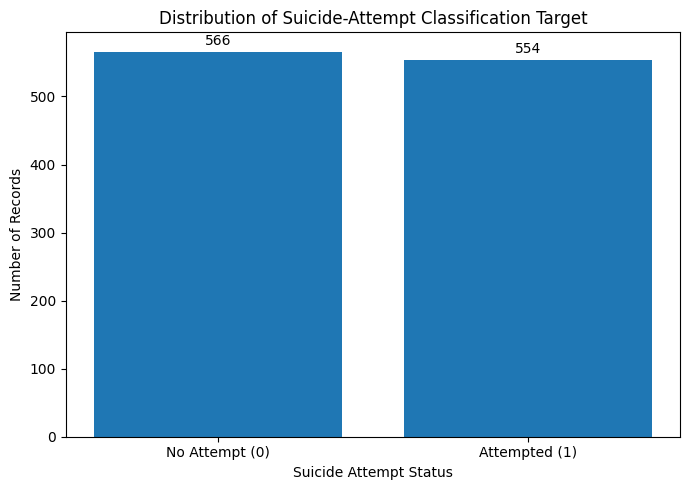

In [ ]:
import matplotlib.pyplot as plt

target_counts = df["Attempted?"].value_counts().sort_index()

plt.figure(figsize=(7, 5))
plt.bar(
    ["No Attempt (0)", "Attempted (1)"],
    target_counts.values
)

plt.title("Distribution of Suicide-Attempt Classification Target")
plt.xlabel("Suicide Attempt Status")
plt.ylabel("Number of Records")

for i, value in enumerate(target_counts.values):
    plt.text(i, value + 10, str(value), ha="center")

plt.tight_layout()
plt.show()

In [ ]:
# ===== FEATURE-TARGET RELATIONSHIP =====

target = "Attempted?"

feature_groups = {
    "Age Group": "Age_Group__",
    "Gender": "Gender__",
    "Religion": "Religion__",
    "Occupation": "Occupation_Standard__",
    "Civil Status": "Civil_Status__",
    "Education Level": "Education_Level__",
    "Psych Session": "Psych_Session__",
    "Disorder": "Disorder__",
    "Alcohol": "Alcohol__",
    "Anger": "Anger__",
    "Sleep Problem": "Sleep_Problem__",
    "Isolation": "Isolation__",
    "Humiliated": "Humiliated__",
    "Sad/Weary": "Sad_Weary__"
}

for feature_name, prefix in feature_groups.items():
    cols = [c for c in df.columns if c.startswith(prefix)]

    if not cols:
        print(f"\n⚠️ {feature_name}: columns not found")
        continue

    print(f"\n===== {feature_name} =====")

    for col in cols:
        group = df[df[col] == 1]

        if len(group) > 0:
            attempt_rate = group[target].mean() * 100

            print(
                f"{col.replace(prefix, '')}: "
                f"n={len(group)}, "
                f"attempt rate={attempt_rate:.2f}%"
            )


===== Age Group =====
15-24: n=232, attempt rate=43.53%
25-34: n=128, attempt rate=56.25%
35-44: n=122, attempt rate=56.56%
45-54: n=123, attempt rate=55.28%
55-64: n=160, attempt rate=54.37%
65-74: n=144, attempt rate=51.39%
75-84: n=126, attempt rate=34.92%
85-94: n=55, attempt rate=43.64%
95+: n=8, attempt rate=37.50%
<15: n=15, attempt rate=33.33%
Unknown/Not reported: n=7, attempt rate=100.00%

===== Gender =====
Female: n=353, attempt rate=28.05%
Male: n=767, attempt rate=59.32%

===== Religion =====
Buddhist: n=249, attempt rate=58.23%
Christian: n=33, attempt rate=9.09%
Hindu: n=63, attempt rate=38.10%
Islam: n=744, attempt rate=51.08%
Other: n=31, attempt rate=6.45%

===== Occupation =====
Administrative Executive Managerial & related workers: n=67, attempt rate=17.91%
Agricultural Animal Husbandry Fisherman & related Forestry workers: n=108, attempt rate=86.11%
Armed Services: n=46, attempt rate=23.91%
Clerical & related workers (Stenographers/ Typists etc): n=59, attempt ra

In [ ]:
print("===== ALL MODEL FEATURES =====\n")

for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

===== ALL MODEL FEATURES =====

 1. Age_Group__15-24
 2. Age_Group__25-34
 3. Age_Group__35-44
 4. Age_Group__45-54
 5. Age_Group__55-64
 6. Age_Group__65-74
 7. Age_Group__75-84
 8. Age_Group__85-94
 9. Age_Group__95+
10. Age_Group__<15
11. Age_Group__Unknown/Not reported
12. Gender__Female
13. Gender__Male
14. Religion__Buddhist
15. Religion__Christian
16. Religion__Hindu
17. Religion__Islam
18. Religion__Other
19. Occupation_Standard__Administrative Executive Managerial & related workers
20. Occupation_Standard__Agricultural Animal Husbandry Fisherman & related Forestry workers
21. Occupation_Standard__Armed Services
22. Occupation_Standard__Clerical & related workers (Stenographers/ Typists etc)
23. Occupation_Standard__Housewife
24. Occupation_Standard__Other
25. Occupation_Standard__Pensioners
26. Occupation_Standard__Police
27. Occupation_Standard__Production process workers Craftsman & related workers transport equipment operators & labourers
28. Occupation_Standard__Profession

In [ ]:
# ============================================================
# FEATURE-WISE TARGET DISTRIBUTION
# ============================================================

target = "Attempted?"

# Automatically identify original feature groups
feature_groups = {}

for col in df.columns:
    if col == target:
        continue

    if "__" in col:
        group = col.split("__")[0]

        if group not in feature_groups:
            feature_groups[group] = []

        feature_groups[group].append(col)

print("===== FEATURE GROUPS DETECTED =====\n")

for group, cols in feature_groups.items():
    print(f"{group}: {len(cols)} categories/features")

===== FEATURE GROUPS DETECTED =====

Age_Group: 11 categories/features
Gender: 2 categories/features
Religion: 5 categories/features
Occupation_Standard: 17 categories/features
Civil Status: 6 categories/features
Education Level: 13 categories/features
Psych Session: 3 categories/features
Disorder: 7 categories/features
Alcohol: 5 categories/features
Anger: 2 categories/features
Sleep Problem: 2 categories/features
Isolation: 3 categories/features
Humiliated: 2 categories/features
Sad/ Weary: 3 categories/features


In [ ]:
# ============================================================
# ATTEMPT RATE BY CATEGORY
# ============================================================

for group, cols in feature_groups.items():

    print("\n" + "=" * 60)
    print(f"{group}")
    print("=" * 60)

    for col in cols:

        n = df[col].sum()

        if n == 0:
            continue

        attempt_rate = df.loc[df[col] == 1, target].mean() * 100

        category = col.split("__", 1)[1]

        print(
            f"{category}: "
            f"n={int(n)}, "
            f"attempt rate={attempt_rate:.2f}%"
        )


Age_Group
15-24: n=232, attempt rate=43.53%
25-34: n=128, attempt rate=56.25%
35-44: n=122, attempt rate=56.56%
45-54: n=123, attempt rate=55.28%
55-64: n=160, attempt rate=54.37%
65-74: n=144, attempt rate=51.39%
75-84: n=126, attempt rate=34.92%
85-94: n=55, attempt rate=43.64%
95+: n=8, attempt rate=37.50%
<15: n=15, attempt rate=33.33%
Unknown/Not reported: n=7, attempt rate=100.00%

Gender
Female: n=353, attempt rate=28.05%
Male: n=767, attempt rate=59.32%

Religion
Buddhist: n=249, attempt rate=58.23%
Christian: n=33, attempt rate=9.09%
Hindu: n=63, attempt rate=38.10%
Islam: n=744, attempt rate=51.08%
Other: n=31, attempt rate=6.45%

Occupation_Standard
Administrative Executive Managerial & related workers: n=67, attempt rate=17.91%
Agricultural Animal Husbandry Fisherman & related Forestry workers: n=108, attempt rate=86.11%
Armed Services: n=46, attempt rate=23.91%
Clerical & related workers (Stenographers/ Typists etc): n=59, attempt rate=16.95%
Housewife: n=6, attempt rate=

In [ ]:
# ============================================================
# MISSING / UNKNOWN CATEGORY AUDIT
# ============================================================

unknown_keywords = [
    "Unknown",
    "Not reported",
    "Not sure"
]

print("===== UNKNOWN / NOT REPORTED CATEGORY AUDIT =====\n")

for group, cols in feature_groups.items():

    for col in cols:

        category = col.split("__", 1)[1]

        if any(keyword.lower() in category.lower()
               for keyword in unknown_keywords):

            n = int(df[col].sum())

            if n > 0:
                attempt_rate = (
                    df.loc[df[col] == 1, "Attempted?"].mean() * 100
                )

                print(
                    f"{group} | {category} | "
                    f"n={n} | "
                    f"attempt rate={attempt_rate:.2f}%"
                )

===== UNKNOWN / NOT REPORTED CATEGORY AUDIT =====

Age_Group | Unknown/Not reported | n=7 | attempt rate=100.00%
Occupation_Standard | Unknown/Not reported | n=23 | attempt rate=95.65%
Civil Status | Unknown/Not reported | n=6 | attempt rate=100.00%
Education Level | Unknown/Not reported | n=16 | attempt rate=93.75%
Psych Session | Not sure | n=1 | attempt rate=100.00%
Disorder | Unknown/Not reported | n=731 | attempt rate=34.61%
Alcohol | Unknown/Not reported | n=273 | attempt rate=100.00%
Isolation | Not sure | n=3 | attempt rate=100.00%
Sad/ Weary | Unknown/Not reported | n=30 | attempt rate=100.00%


In [ ]:
# Check whether unknown categories are concentrated in one target class

print("\n===== UNKNOWN CATEGORY × TARGET =====\n")

for group, cols in feature_groups.items():

    for col in cols:

        category = col.split("__", 1)[1]

        if any(keyword.lower() in category.lower()
               for keyword in unknown_keywords):

            n = int(df[col].sum())

            if n > 0:
                counts = df.loc[df[col] == 1, "Attempted?"].value_counts()

                print(f"\n{group} → {category}")
                print(counts)


===== UNKNOWN CATEGORY × TARGET =====


Age_Group → Unknown/Not reported
Attempted?
1    7
Name: count, dtype: int64

Occupation_Standard → Unknown/Not reported
Attempted?
1    22
0     1
Name: count, dtype: int64

Civil Status → Unknown/Not reported
Attempted?
1    6
Name: count, dtype: int64

Education Level → Unknown/Not reported
Attempted?
1    15
0     1
Name: count, dtype: int64

Psych Session → Not sure
Attempted?
1    1
Name: count, dtype: int64

Disorder → Unknown/Not reported
Attempted?
0    478
1    253
Name: count, dtype: int64

Alcohol → Unknown/Not reported
Attempted?
1    273
Name: count, dtype: int64

Isolation → Not sure
Attempted?
1    3
Name: count, dtype: int64

Sad/ Weary → Unknown/Not reported
Attempted?
1    30
Name: count, dtype: int64


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving original_dataset.csv to original_dataset.csv


In [ ]:
# ============================================================
# RAW DATA — MISSINGNESS VS TARGET AUDIT
# ============================================================

import pandas as pd
import numpy as np

raw_df = pd.read_csv("original_dataset.csv")

target = "Attempted?"

print("Raw dataset shape:", raw_df.shape)

print("\n===== MISSINGNESS BY VARIABLE =====\n")

results = []

for col in raw_df.columns:

    if col == target:
        continue

    missing_mask = raw_df[col].isna()

    missing_n = missing_mask.sum()

    if missing_n == 0:
        continue

    missing_target_0 = (
        raw_df.loc[missing_mask, target] == 0
    ).sum()

    missing_target_1 = (
        raw_df.loc[missing_mask, target] == 1
    ).sum()

    missing_attempt_rate = (
        missing_target_1 / missing_n * 100
    )

    nonmissing_mask = ~missing_mask

    nonmissing_attempt_rate = (
        raw_df.loc[nonmissing_mask, target].mean() * 100
    )

    results.append({
        "Variable": col,
        "Missing": int(missing_n),
        "Missing_Target_0": int(missing_target_0),
        "Missing_Target_1": int(missing_target_1),
        "Missing_Attempt_Rate_%": round(missing_attempt_rate, 2),
        "NonMissing_Attempt_Rate_%": round(
            nonmissing_attempt_rate, 2
        )
    })

missing_audit = pd.DataFrame(results)

missing_audit = missing_audit.sort_values(
    "Missing_Attempt_Rate_%",
    ascending=False
)

display(missing_audit)

Raw dataset shape: (1128, 17)

===== MISSINGNESS BY VARIABLE =====



,Variable,Missing,Missing_Target_0,Missing_Target_1,Missing_Attempt_Rate_%,NonMissing_Attempt_Rate_%
0,Age,7,0,7,100.00,48.88
1,Occupation,22,0,22,100.00,48.19
2,Civil Status,6,0,6,100.00,48.93
7,Sad/ Weary,30,0,30,100.00,47.81
6,Alcohol,274,0,274,100.00,32.90
3,Education Level,16,1,15,93.75,48.56
5,Illness,45,22,23,51.11,49.12
4,Disorder,738,485,253,34.28,77.44


In [ ]:
print("\n===== RAW MISSINGNESS SUMMARY =====")

print(
    "Total missing cells:",
    raw_df.isna().sum().sum()
)

print(
    "Variables containing missing values:",
    (raw_df.isna().sum() > 0).sum()
)

display(
    raw_df.isna().sum()
    .sort_values(ascending=False)
    .loc[lambda x: x > 0]
)


===== RAW MISSINGNESS SUMMARY =====
Total missing cells: 1138
Variables containing missing values: 8


,0
Disorder,738
Alcohol,274
Illness,45
Sad/ Weary,30
Occupation,22
Education Level,16
Age,7
Civil Status,6


In [ ]:
# ============================================================
# IMPORTANT RAW MISSINGNESS × TARGET CHECK
# ============================================================

check_cols = [
    "Alcohol",
    "Sad/Weary",
    "Age",
    "Occupation",
    "Education Level",
    "Civil Status",
    "Disorder",
    "Illness"
]

for col in check_cols:

    missing = raw_df[col].isna()

    if missing.sum() == 0:
        continue

    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    print("Missing:", missing.sum())

    print("\nTarget distribution among MISSING:")
    print(raw_df.loc[missing, "Attempted?"].value_counts().sort_index())

    print("\nTarget distribution among NON-MISSING:")
    print(raw_df.loc[~missing, "Attempted?"].value_counts().sort_index())

    print(
        "\nMissing → Attempt rate:",
        round(raw_df.loc[missing, "Attempted?"].mean() * 100, 2),
        "%"
    )

    print(
        "Non-missing → Attempt rate:",
        round(raw_df.loc[~missing, "Attempted?"].mean() * 100, 2),
        "%"
    )


Alcohol
Missing: 274

Target distribution among MISSING:
Attempted?
1.0    274
Name: count, dtype: int64

Target distribution among NON-MISSING:
Attempted?
0.0    573
1.0    281
Name: count, dtype: int64

Missing → Attempt rate: 100.0 %
Non-missing → Attempt rate: 32.9 %


KeyError: 'Sad/Weary'

In [ ]:
# ============================================================
# IMPORTANT RAW MISSINGNESS × TARGET CHECK
# ============================================================

check_cols = [
    "Alcohol",
    "Sad/ Weary",       # Correct column name
    "Age",
    "Occupation",
    "Education Level",
    "Civil Status",
    "Disorder",
    "Illness"
]

for col in check_cols:

    missing = raw_df[col].isna()

    if missing.sum() == 0:
        continue

    print("\n" + "=" * 60)
    print(col)
    print("=" * 60)

    print("Missing:", missing.sum())

    print("\nTarget distribution among MISSING:")
    print(
        raw_df.loc[missing, "Attempted?"]
        .value_counts()
        .sort_index()
    )

    print("\nTarget distribution among NON-MISSING:")
    print(
        raw_df.loc[~missing, "Attempted?"]
        .value_counts()
        .sort_index()
    )

    print(
        "\nMissing → Attempt rate:",
        round(
            raw_df.loc[missing, "Attempted?"].mean() * 100,
            2
        ),
        "%"
    )

    print(
        "Non-missing → Attempt rate:",
        round(
            raw_df.loc[~missing, "Attempted?"].mean() * 100,
            2
        ),
        "%"
    )


Alcohol
Missing: 274

Target distribution among MISSING:
Attempted?
1.0    274
Name: count, dtype: int64

Target distribution among NON-MISSING:
Attempted?
0.0    573
1.0    281
Name: count, dtype: int64

Missing → Attempt rate: 100.0 %
Non-missing → Attempt rate: 32.9 %

Sad/ Weary
Missing: 30

Target distribution among MISSING:
Attempted?
1.0    30
Name: count, dtype: int64

Target distribution among NON-MISSING:
Attempted?
0.0    573
1.0    525
Name: count, dtype: int64

Missing → Attempt rate: 100.0 %
Non-missing → Attempt rate: 47.81 %

Age
Missing: 7

Target distribution among MISSING:
Attempted?
1.0    7
Name: count, dtype: int64

Target distribution among NON-MISSING:
Attempted?
0.0    573
1.0    548
Name: count, dtype: int64

Missing → Attempt rate: 100.0 %
Non-missing → Attempt rate: 48.88 %

Occupation
Missing: 22

Target distribution among MISSING:
Attempted?
1.0    22
Name: count, dtype: int64

Target distribution among NON-MISSING:
Attempted?
0.0    573
1.0    533
Name: 

In [ ]:
# ============================================================
# REMAINING HIGH-MISSING VARIABLES
# ============================================================

for col in ["Disorder", "Illness"]:

    missing = raw_df[col].isna()

    print("\n" + "=" * 65)
    print(col)
    print("=" * 65)

    print("Missing:", int(missing.sum()))

    print("\nMissing × Target:")
    print(
        raw_df.loc[missing, "Attempted?"]
        .value_counts()
        .sort_index()
    )

    print("\nNon-missing × Target:")
    print(
        raw_df.loc[~missing, "Attempted?"]
        .value_counts()
        .sort_index()
    )

    print(
        "\nMissing → Attempt rate:",
        round(raw_df.loc[missing, "Attempted?"].mean() * 100, 2),
        "%"
    )

    print(
        "Non-missing → Attempt rate:",
        round(raw_df.loc[~missing, "Attempted?"].mean() * 100, 2),
        "%"
    )


Disorder
Missing: 738

Missing × Target:
Attempted?
0.0    485
1.0    253
Name: count, dtype: int64

Non-missing × Target:
Attempted?
0.0     88
1.0    302
Name: count, dtype: int64

Missing → Attempt rate: 34.28 %
Non-missing → Attempt rate: 77.44 %

Illness
Missing: 45

Missing × Target:
Attempted?
0.0    22
1.0    23
Name: count, dtype: int64

Non-missing × Target:
Attempted?
0.0    551
1.0    532
Name: count, dtype: int64

Missing → Attempt rate: 51.11 %
Non-missing → Attempt rate: 49.12 %


In [ ]:
# ============================================================
# CATEGORICAL FEATURE vs TARGET
# CHI-SQUARE TEST + CRAMER'S V
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Load original cleaned categorical dataset
clean_df = pd.read_csv("cleaned_reproducible_dataset(1).csv")

target = "Attempted?"

# Features for association analysis
features = [
    "Age_Group",
    "Gender",
    "Religion",
    "Occupation_Standard",
    "Civil Status",
    "Education Level",
    "Psych Session",
    "Disorder",
    "Alcohol",
    "Anger",
    "Sleep Problem",
    "Isolation",
    "Humiliated",
    "Sad/ Weary"
]

results = []

for feature in features:

    # Remove missing target only
    temp = clean_df[[feature, target]].dropna()

    # Contingency table
    table = pd.crosstab(temp[feature], temp[target])

    # Chi-square
    chi2, p, dof, expected = chi2_contingency(table)

    # Cramer's V
    n = table.values.sum()
    r, k = table.shape

    phi2 = chi2 / n

    # Bias-corrected Cramer's V
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(kcorr - 1, rcorr - 1)

    if denominator > 0:
        cramers_v = np.sqrt(phi2corr / denominator)
    else:
        cramers_v = 0

    results.append({
        "Feature": feature,
        "Chi2": chi2,
        "p_value": p,
        "Cramers_V": cramers_v,
        "Categories": table.shape[0],
        "N": n
    })

association_df = pd.DataFrame(results)

association_df = association_df.sort_values(
    "Cramers_V",
    ascending=False
).reset_index(drop=True)

print("===== CHI-SQUARE + CRAMER'S V =====")

display(
    association_df.style.format({
        "Chi2": "{:.2f}",
        "p_value": "{:.4e}",
        "Cramers_V": "{:.3f}"
    })
)

FileNotFoundError: [Errno 2] No such file or directory: 'cleaned_reproducible_dataset(1).csv'

In [ ]:
# ============================================================
# CHI-SQUARE TEST + CRAMER'S V
# RAW DATASET
# ============================================================

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

# Load YOUR uploaded raw dataset
raw_df = pd.read_csv("original_dataset.csv")

target = "Attempted?"

print("Dataset shape:", raw_df.shape)

# Features available in the original dataset
features = [
    "Age",
    "Gender",
    "Religion",
    "Occupation",
    "Civil Status",
    "Education Level",
    "Psych Session",
    "Past Attempt",
    "Disorder",
    "Illness",
    "Alcohol",
    "Anger",
    "Sleep Problem",
    "Isolation",
    "Humiliated",
    "Sad/ Weary"
]

results = []

for feature in features:

    # Skip missing values for this feature
    temp = raw_df[[feature, target]].dropna()

    # Contingency table
    table = pd.crosstab(
        temp[feature],
        temp[target]
    )

    # Chi-square test
    chi2, p, dof, expected = chi2_contingency(table)

    # Cramer's V
    n = table.values.sum()
    r, k = table.shape

    phi2 = chi2 / n

    # Bias-corrected Cramer's V
    phi2corr = max(
        0,
        phi2 - ((k - 1) * (r - 1)) / (n - 1)
    )

    rcorr = r - ((r - 1) ** 2) / (n - 1)
    kcorr = k - ((k - 1) ** 2) / (n - 1)

    denominator = min(
        kcorr - 1,
        rcorr - 1
    )

    if denominator > 0:
        cramers_v = np.sqrt(
            phi2corr / denominator
        )
    else:
        cramers_v = 0

    results.append({
        "Feature": feature,
        "Chi2": chi2,
        "p_value": p,
        "Cramers_V": cramers_v,
        "Categories": table.shape[0],
        "N": n
    })

association_df = pd.DataFrame(results)

association_df = association_df.sort_values(
    "Cramers_V",
    ascending=False
).reset_index(drop=True)

print("\n===== CHI-SQUARE + CRAMER'S V =====")

display(
    association_df.style.format({
        "Chi2": "{:.2f}",
        "p_value": "{:.4e}",
        "Cramers_V": "{:.3f}"
    })
)

Dataset shape: (1128, 17)

===== CHI-SQUARE + CRAMER'S V =====


,Feature,Chi2,p_value,Cramers_V,Categories,N
0,Past Attempt,1067.16,9.9502e-230,0.971,5,1128
1,Alcohol,592.06,5.3156e-128,0.831,4,854
2,Anger,550.94,4.3436e-119,0.697,4,1128
3,Sad/ Weary,516.05,3.0565e-114,0.685,2,1098
4,Isolation,507.71,1.4409e-108,0.669,5,1128
5,Humiliated,438.82,8.6063e-95,0.622,4,1128
6,Occupation,449.71,2.8293e-71,0.610,40,1106
7,Education Level,377.94,1.7609e-73,0.574,13,1112
8,Psych Session,304.95,9.2887e-65,0.517,5,1128
9,Sleep Problem,292.37,4.4493e-63,0.507,4,1128


In [ ]:
print("===== STRONG ASSOCIATION SCREEN =====")

strong = association_df[
    association_df["Cramers_V"] >= 0.50
]

display(
    strong.style.format({
        "Chi2": "{:.2f}",
        "p_value": "{:.4e}",
        "Cramers_V": "{:.3f}"
    })
)

===== STRONG ASSOCIATION SCREEN =====


,Feature,Chi2,p_value,Cramers_V,Categories,N
0,Past Attempt,1067.16,9.9502e-230,0.971,5,1128
1,Alcohol,592.06,5.3156e-128,0.831,4,854
2,Anger,550.94,4.3436e-119,0.697,4,1128
3,Sad/ Weary,516.05,3.0565e-114,0.685,2,1098
4,Isolation,507.71,1.4409e-108,0.669,5,1128
5,Humiliated,438.82,8.6063e-95,0.622,4,1128
6,Occupation,449.71,2.8293e-71,0.610,40,1106
7,Education Level,377.94,1.7609e-73,0.574,13,1112
8,Psych Session,304.95,9.2887e-65,0.517,5,1128
9,Sleep Problem,292.37,4.4493e-63,0.507,4,1128


In [ ]:
# ============================================================
# DETAILED AUDIT OF HIGH-ASSOCIATION FEATURES
# ============================================================

audit_features = [
    "Alcohol",
    "Anger",
    "Sad/ Weary",
    "Isolation",
    "Humiliated",
    "Psych Session",
    "Sleep Problem",
    "Occupation",
    "Education Level"
]

for feature in audit_features:

    print("\n" + "=" * 70)
    print(feature)
    print("=" * 70)

    table = pd.crosstab(
        raw_df[feature],
        raw_df["Attempted?"],
        margins=True
    )

    print(table)


Alcohol
Attempted?  0.0  1.0  All
Alcohol                  
Frequent     26  151  177
Medium        9    6   15
Moderate     17  106  123
No          521   18  539
All         573  281  854

Anger
Attempted?  0.0  1.0   All
Anger                     
0           434  106   540
1            41  419   460
No           50    7    57
Yes          48   23    71
All         573  555  1128

Sad/ Weary
Attempted?  0.0  1.0   All
Sad/ Weary                
0.0         544  150   694
1.0          29  375   404
All         573  525  1098

Isolation
Attempted?  0.0  1.0   All
Isolation                 
0           440  135   575
1            35  390   425
No           79   14    93
Not Sure      0    3     3
Yes          19   13    32
All         573  555  1128

Humiliated
Attempted?  0.0  1.0   All
Humiliated                
0           451  187   638
1            24  338   362
No           71    5    76
Yes          27   25    52
All         573  555  1128

Psych Session
Attempted?     0.0  1.0

In [ ]:
# ============================================================
# NEAR-DETERMINISTIC FEATURE PATTERN CHECK
# ============================================================

check_features = [
    "Alcohol",
    "Anger",
    "Sad/ Weary",
    "Isolation",
    "Humiliated",
    "Psych Session",
    "Sleep Problem"
]

for feature in check_features:

    temp = raw_df[[feature, "Attempted?"]].dropna()

    grouped = (
        temp.groupby(feature)["Attempted?"]
        .agg(["count", "mean"])
        .sort_values("mean", ascending=False)
    )

    print("\n" + "=" * 60)
    print(feature)
    print("=" * 60)

    grouped["attempt_rate_%"] = (
        grouped["mean"] * 100
    )

    display(
        grouped[["count", "attempt_rate_%"]]
        .round(2)
    )


Alcohol


,count,attempt_rate_%
Alcohol,,
Moderate,123,86.18
Frequent,177,85.31
Medium,15,40.00
No,539,3.34



Anger


,count,attempt_rate_%
Anger,,
1,460,91.09
Yes,71,32.39
0,540,19.63
No,57,12.28



Sad/ Weary


...

,count,attempt_rate_%
Humiliated,,
1,362,93.37
Yes,52,48.08
0,638,29.31
No,76,6.58



Psych Session


,count,attempt_rate_%
Psych Session,,
Not sure,1,100.00
1,234,98.72
Yes,13,46.15
0,766,38.38
No,114,20.18



Sleep Problem


,count,attempt_rate_%
Sleep Problem,,
1,621,71.98
Yes,62,33.87
0,379,20.58
No,66,13.64


In [ ]:
# ============================================================
# TARGET RECONSTRUCTION / DETERMINISTIC PATTERN AUDIT
# ============================================================

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# df = model-ready dataset already loaded

X_audit = df.drop(columns=["Attempted?"])
y_audit = df["Attempted?"]

print("Features used:", X_audit.shape[1])
print("Rows:", X_audit.shape[0])

# Very shallow tree: audit only, NOT final model
audit_tree = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

audit_tree.fit(X_audit, y_audit)

train_pred = audit_tree.predict(X_audit)

train_accuracy = accuracy_score(
    y_audit,
    train_pred
)

print("\n===== TARGET RECONSTRUCTION AUDIT =====")
print("Training accuracy:", round(train_accuracy, 4))

print("\nConfusion matrix:")
print(confusion_matrix(y_audit, train_pred))

Features used: 81
Rows: 1120

===== TARGET RECONSTRUCTION AUDIT =====
Training accuracy: 0.9598

Confusion matrix:
[[550  16]
 [ 29 525]]


In [ ]:
# ============================================================
# TARGET RECONSTRUCTION AUDIT — FEATURE IMPORTANCE
# ============================================================

importance_df = pd.DataFrame({
    "Feature": X_audit.columns,
    "Importance": audit_tree.feature_importances_
})

importance_df = importance_df[
    importance_df["Importance"] > 0
].sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

print("===== AUDIT TREE FEATURE IMPORTANCE =====")

display(
    importance_df.style.format({
        "Importance": "{:.4f}"
    })
)

===== AUDIT TREE FEATURE IMPORTANCE =====


,Feature,Importance
0,Alcohol__No,0.8619
1,Sad/ Weary__Unknown/Not reported,0.0697
2,Anger__No,0.0356
3,Sad/ Weary__0.0,0.0317
4,Occupation_Standard__Pensioners,0.0012


In [ ]:
from sklearn.tree import export_text

print("===== AUDIT TREE RULES =====\n")

rules = export_text(
    audit_tree,
    feature_names=list(X_audit.columns)
)

print(rules)

===== AUDIT TREE RULES =====

|--- Alcohol__No <= 0.50
|   |--- Sad/ Weary__0.0 <= 0.50
|   |   |--- Occupation_Standard__Pensioners <= 0.50
|   |   |   |--- class: 1
|   |   |--- Occupation_Standard__Pensioners >  0.50
|   |   |   |--- class: 1
|   |--- Sad/ Weary__0.0 >  0.50
|   |   |--- Anger__No <= 0.50
|   |   |   |--- class: 1
|   |   |--- Anger__No >  0.50
|   |   |   |--- class: 0
|--- Alcohol__No >  0.50
|   |--- Sad/ Weary__Unknown/Not reported <= 0.50
|   |   |--- class: 0
|   |--- Sad/ Weary__Unknown/Not reported >  0.50
|   |   |--- class: 1



In [ ]:
# ============================================================
# ALCOHOL-ONLY TARGET RECONSTRUCTION AUDIT
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

temp = raw_df[["Alcohol", "Attempted?"]].copy()

# Create a simple rule:
# Alcohol = No -> predict 0
# Anything else -> predict 1
#
# Missing Alcohol is also treated as non-No,
# therefore predicted as 1.

pred = np.where(
    temp["Alcohol"] == "No",
    0,
    1
)

y_true = temp["Attempted?"]

print("===== ALCOHOL-ONLY RULE AUDIT =====")

print(
    "Accuracy:",
    round(accuracy_score(y_true, pred), 4)
)

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, pred))

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        pred,
        digits=4
    )
)

===== ALCOHOL-ONLY RULE AUDIT =====
Accuracy: 0.9379

Confusion Matrix:
[[521  52]
 [ 18 537]]

Classification Report:
              precision    recall  f1-score   support

         0.0     0.9666    0.9092    0.9371       573
         1.0     0.9117    0.9676    0.9388       555

    accuracy                         0.9379      1128
   macro avg     0.9392    0.9384    0.9379      1128
weighted avg     0.9396    0.9379    0.9379      1128



In [ ]:
# ============================================================
# SENSITIVITY AUDIT — REMOVE ALCOHOL
# ============================================================

X_no_alcohol = df.drop(
    columns=["Attempted?"] +
            [c for c in df.columns if c.startswith("Alcohol__")]
)

y = df["Attempted?"]

print("Original features:", df.shape[1] - 1)
print("Features after removing Alcohol:", X_no_alcohol.shape[1])

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

tree_no_alcohol = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_no_alcohol.fit(X_no_alcohol, y)

pred_no_alcohol = tree_no_alcohol.predict(X_no_alcohol)

print("\n===== WITHOUT ALCOHOL =====")

print(
    "Training accuracy:",
    round(accuracy_score(y, pred_no_alcohol), 4)
)

print("\nConfusion matrix:")
print(confusion_matrix(y, pred_no_alcohol))

Original features: 81
Features after removing Alcohol: 76

===== WITHOUT ALCOHOL =====
Training accuracy: 0.9232

Confusion matrix:
[[514  52]
 [ 34 520]]


In [ ]:
# ============================================================
# SENSITIVITY AUDIT 2 — REMOVE ALCOHOL + MISSINGNESS SIGNAL
# ============================================================

# Remove target
drop_cols = ["Attempted?"]

# Remove all Alcohol encoded columns
drop_cols += [
    c for c in df.columns
    if c.startswith("Alcohol__")
]

# Remove explicit missing/unknown indicator columns
drop_cols += [
    c for c in df.columns
    if "__Unknown/Not reported" in c
]

X_sensitivity = df.drop(columns=drop_cols)
y = df["Attempted?"]

print("Original features:", df.shape[1] - 1)
print("Features after removing Alcohol + Unknown indicators:",
      X_sensitivity.shape[1])

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

tree_sensitivity = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

tree_sensitivity.fit(X_sensitivity, y)

pred_sensitivity = tree_sensitivity.predict(X_sensitivity)

print("\n===== WITHOUT ALCOHOL + MISSINGNESS SIGNAL =====")

print(
    "Training accuracy:",
    round(accuracy_score(y, pred_sensitivity), 4)
)

print("\nConfusion matrix:")
print(confusion_matrix(y, pred_sensitivity))

Original features: 81
Features after removing Alcohol + Unknown indicators: 70

===== WITHOUT ALCOHOL + MISSINGNESS SIGNAL =====
Training accuracy: 0.9232

Confusion matrix:
[[514  52]
 [ 34 520]]


In [ ]:
# ============================================================
# STEP 1 — TRAIN / TEST SPLIT
# ============================================================

from sklearn.model_selection import train_test_split

# Target
y = df["Attempted?"]

# Predictors
# Past Attempt is already excluded from df
X = df.drop(columns=["Attempted?"])

print("Dataset shape:", X.shape)
print("Target shape:", y.shape)

# ------------------------------------------------------------
# 80% Training / 20% Test
# Stratified = preserve class distribution
# ------------------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\n===== TRAIN / TEST SPLIT =====")

print("Training samples:", X_train.shape[0])
print("Test samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTraining target percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTest target distribution:")
print(y_test.value_counts())

print("\nTest target percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))

Dataset shape: (1120, 81)
Target shape: (1120,)

===== TRAIN / TEST SPLIT =====
Training samples: 896
Test samples: 224

Training target distribution:
Attempted?
0    453
1    443
Name: count, dtype: int64

Training target percentage:
Attempted?
0    50.56
1    49.44
Name: proportion, dtype: float64

Test target distribution:
Attempted?
0    113
1    111
Name: count, dtype: int64

Test target percentage:
Attempted?
0    50.45
1    49.55
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# STEP 2 — 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print("===== 5-FOLD STRATIFIED CROSS-VALIDATION =====")

print("Number of folds:", cv.n_splits)
print("Shuffle:", cv.shuffle)
print("Random state:", cv.random_state)

print("\nTraining dataset size:", len(X_train))
print("Test dataset size:", len(X_test))

# Check each fold
for fold, (train_idx, val_idx) in enumerate(
    cv.split(X_train, y_train), start=1
):

    y_fold_train = y_train.iloc[train_idx]
    y_fold_val = y_train.iloc[val_idx]

    print(f"\nFold {fold}")
    print("  Train samples:", len(train_idx))
    print("  Validation samples:", len(val_idx))
    print(
        "  Train class distribution:",
        y_fold_train.value_counts().to_dict()
    )
    print(
        "  Validation class distribution:",
        y_fold_val.value_counts().to_dict()
    )

===== 5-FOLD STRATIFIED CROSS-VALIDATION =====
Number of folds: 5
Shuffle: True
Random state: 42

Training dataset size: 896
Test dataset size: 224

Fold 1
  Train samples: 716
  Validation samples: 180
  Train class distribution: {0: 362, 1: 354}
  Validation class distribution: {0: 91, 1: 89}

Fold 2
  Train samples: 717
  Validation samples: 179
  Train class distribution: {0: 362, 1: 355}
  Validation class distribution: {0: 91, 1: 88}

Fold 3
  Train samples: 717
  Validation samples: 179
  Train class distribution: {0: 362, 1: 355}
  Validation class distribution: {0: 91, 1: 88}

Fold 4
  Train samples: 717
  Validation samples: 179
  Train class distribution: {0: 363, 1: 354}
  Validation class distribution: {0: 90, 1: 89}

Fold 5
  Train samples: 717
  Validation samples: 179
  Train class distribution: {0: 363, 1: 354}
  Validation class distribution: {0: 90, 1: 89}


In [ ]:
# ============================================================
# STEP 3 — LOGISTIC REGRESSION
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    make_scorer,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Specificity scorer
# ------------------------------------------------------------

def specificity_score(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(
        y_true, y_pred
    ).ravel()

    return tn / (tn + fp)

# ------------------------------------------------------------
# Logistic Regression Pipeline
# ------------------------------------------------------------

logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

# ------------------------------------------------------------
# Scoring metrics
# ------------------------------------------------------------

scoring = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(
        precision_score,
        zero_division=0
    ),
    "recall": make_scorer(
        recall_score,
        zero_division=0
    ),
    "f1": make_scorer(
        f1_score,
        zero_division=0
    ),
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
    "specificity": make_scorer(
        specificity_score
    )
}

# ------------------------------------------------------------
# 5-Fold Cross-Validation
# ------------------------------------------------------------

logistic_cv = cross_validate(
    logistic_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 60)
print("LOGISTIC REGRESSION — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

metrics = [
    "accuracy",
    "precision",
    "recall",
    "specificity",
    "f1",
    "roc_auc",
    "average_precision"
]

for metric in metrics:

    scores = logistic_cv[
        "test_" + metric
    ]

    print(
        f"{metric.upper():20s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

LOGISTIC REGRESSION — 5-FOLD CROSS-VALIDATION
ACCURACY            : 0.9855 ± 0.0109
PRECISION           : 0.9781 ± 0.0192
RECALL              : 0.9932 ± 0.0055
SPECIFICITY         : 0.9779 ± 0.0198
F1                  : 0.9855 ± 0.0107
ROC_AUC             : 0.9989 ± 0.0008
AVERAGE_PRECISION   : 0.9989 ± 0.0008


In [ ]:
# ============================================================
# STEP 4 — DECISION TREE
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from sklearn.tree import DecisionTreeClassifier

decision_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

decision_tree_cv = cross_validate(
    decision_tree,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("=" * 60)
print("DECISION TREE — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

for metric in metrics:

    scores = decision_tree_cv[
        "test_" + metric
    ]

    print(
        f"{metric.upper():20s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

DECISION TREE — 5-FOLD CROSS-VALIDATION
ACCURACY            : 0.9654 ± 0.0178
PRECISION           : 0.9547 ± 0.0303
RECALL              : 0.9774 ± 0.0101
SPECIFICITY         : 0.9536 ± 0.0325
F1                  : 0.9657 ± 0.0171
ROC_AUC             : 0.9734 ± 0.0201
AVERAGE_PRECISION   : 0.9567 ± 0.0331


In [ ]:
# ============================================================
# STEP 5 — RANDOM FOREST
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from sklearn.ensemble import RandomForestClassifier

random_forest = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

random_forest_cv = cross_validate(
    random_forest,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("=" * 60)
print("RANDOM FOREST — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

for metric in metrics:

    scores = random_forest_cv[
        "test_" + metric
    ]

    print(
        f"{metric.upper():20s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

RANDOM FOREST — 5-FOLD CROSS-VALIDATION
ACCURACY            : 0.9810 ± 0.0104
PRECISION           : 0.9780 ± 0.0193
RECALL              : 0.9842 ± 0.0055
SPECIFICITY         : 0.9779 ± 0.0198
F1                  : 0.9810 ± 0.0102
ROC_AUC             : 0.9988 ± 0.0010
AVERAGE_PRECISION   : 0.9988 ± 0.0011


In [ ]:
# ============================================================
# STEP 6 — SVM (RBF)
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

svm_cv = cross_validate(
    svm_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("=" * 60)
print("SVM (RBF) — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

for metric in metrics:

    scores = svm_cv[
        "test_" + metric
    ]

    print(
        f"{metric.upper():20s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

SVM (RBF) — 5-FOLD CROSS-VALIDATION
ACCURACY            : 0.9732 ± 0.0096
PRECISION           : 0.9775 ± 0.0118
RECALL              : 0.9684 ± 0.0193
SPECIFICITY         : 0.9779 ± 0.0122
F1                  : 0.9728 ± 0.0099
ROC_AUC             : 0.9984 ± 0.0008
AVERAGE_PRECISION   : 0.9984 ± 0.0007


In [ ]:
# ============================================================
# STEP 7 — XGBOOST
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_cv = cross_validate(
    xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

print("=" * 60)
print("XGBOOST — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

for metric in metrics:

    scores = xgb_cv[
        "test_" + metric
    ]

    print(
        f"{metric.upper():20s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

ValueError: 
All the 5 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
5 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.13/dist-packages/xgboost/core.py", line 569, in inner_f
    return func(**kwargs)
  File "/usr/local/lib/python3.13/dist-packages/xgboost/sklearn.py", line 1838, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ~~~~~~~~~~~~~~~~~~~~~~~~~^
        missing=self.missing,
        ^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
        feature_types=feature_types,
      

In [ ]:
# ============================================================
# STEP 7 — XGBOOST
# FIXED FEATURE NAMES
# 5-FOLD STRATIFIED CROSS-VALIDATION
# ============================================================

from xgboost import XGBClassifier

# ------------------------------------------------------------
# XGBoost does not allow [, ] or < in feature names.
# Create a copy so the original df/X_train remain unchanged.
# ------------------------------------------------------------

X_train_xgb = X_train.copy()

X_train_xgb.columns = (
    X_train_xgb.columns
    .astype(str)
    .str.replace("[", "(", regex=False)
    .str.replace("]", ")", regex=False)
    .str.replace("<", "less_than_", regex=False)
    .str.replace(">", "greater_than_", regex=False)
)

# Check feature names
invalid_features = [
    col for col in X_train_xgb.columns
    if any(char in col for char in ["[", "]", "<"])
]

print("Number of features:", X_train_xgb.shape[1])
print("Invalid feature names:", len(invalid_features))

# ------------------------------------------------------------
# XGBoost model
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

# ------------------------------------------------------------
# 5-Fold Cross-Validation
# ------------------------------------------------------------

xgb_cv = cross_validate(
    xgb_model,
    X_train_xgb,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=False,
    n_jobs=-1
)

# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("XGBOOST — 5-FOLD CROSS-VALIDATION")
print("=" * 60)

for metric in metrics:

    scores = xgb_cv[
        "test_" + metric
    ]

    print(
        f"{metric.upper():20s}: "
        f"{scores.mean():.4f} ± {scores.std():.4f}"
    )

Number of features: 81
Invalid feature names: 0

XGBOOST — 5-FOLD CROSS-VALIDATION
ACCURACY            : 0.9832 ± 0.0106
PRECISION           : 0.9802 ± 0.0184
RECALL              : 0.9865 ± 0.0085
SPECIFICITY         : 0.9801 ± 0.0191
F1                  : 0.9832 ± 0.0104
ROC_AUC             : 0.9985 ± 0.0010
AVERAGE_PRECISION   : 0.9984 ± 0.0010


In [ ]:
# ============================================================
# STEP 8 — CREATE MODEL COMPARISON TABLE
# ============================================================

import pandas as pd

cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM (RBF)",
        "XGBoost"
    ],

    "Accuracy_Mean": [
        logistic_cv["test_accuracy"].mean(),
        decision_tree_cv["test_accuracy"].mean(),
        random_forest_cv["test_accuracy"].mean(),
        svm_cv["test_accuracy"].mean(),
        xgb_cv["test_accuracy"].mean()
    ],

    "Accuracy_SD": [
        logistic_cv["test_accuracy"].std(),
        decision_tree_cv["test_accuracy"].std(),
        random_forest_cv["test_accuracy"].std(),
        svm_cv["test_accuracy"].std(),
        xgb_cv["test_accuracy"].std()
    ],

    "Precision_Mean": [
        logistic_cv["test_precision"].mean(),
        decision_tree_cv["test_precision"].mean(),
        random_forest_cv["test_precision"].mean(),
        svm_cv["test_precision"].mean(),
        xgb_cv["test_precision"].mean()
    ],

    "Recall_Mean": [
        logistic_cv["test_recall"].mean(),
        decision_tree_cv["test_recall"].mean(),
        random_forest_cv["test_recall"].mean(),
        svm_cv["test_recall"].mean(),
        xgb_cv["test_recall"].mean()
    ],

    "Specificity_Mean": [
        logistic_cv["test_specificity"].mean(),
        decision_tree_cv["test_specificity"].mean(),
        random_forest_cv["test_specificity"].mean(),
        svm_cv["test_specificity"].mean(),
        xgb_cv["test_specificity"].mean()
    ],

    "F1_Mean": [
        logistic_cv["test_f1"].mean(),
        decision_tree_cv["test_f1"].mean(),
        random_forest_cv["test_f1"].mean(),
        svm_cv["test_f1"].mean(),
        xgb_cv["test_f1"].mean()
    ],

    "ROC_AUC_Mean": [
        logistic_cv["test_roc_auc"].mean(),
        decision_tree_cv["test_roc_auc"].mean(),
        random_forest_cv["test_roc_auc"].mean(),
        svm_cv["test_roc_auc"].mean(),
        xgb_cv["test_roc_auc"].mean()
    ],

    "AP_Mean": [
        logistic_cv["test_average_precision"].mean(),
        decision_tree_cv["test_average_precision"].mean(),
        random_forest_cv["test_average_precision"].mean(),
        svm_cv["test_average_precision"].mean(),
        xgb_cv["test_average_precision"].mean()
    ]
})

# Round for readability
cv_results = cv_results.round(4)

print("=" * 80)
print("MODEL COMPARISON — 5-FOLD CROSS-VALIDATION")
print("=" * 80)

display(cv_results)

MODEL COMPARISON — 5-FOLD CROSS-VALIDATION


,Model,Accuracy_Mean,Accuracy_SD,Precision_Mean,Recall_Mean,Specificity_Mean,F1_Mean,ROC_AUC_Mean,AP_Mean
0,Logistic Regression,0.9855,0.0109,0.9781,0.9932,0.9779,0.9855,0.9989,0.9989
1,Decision Tree,0.9654,0.0178,0.9547,0.9774,0.9536,0.9657,0.9734,0.9567
2,Random Forest,0.9810,0.0104,0.9780,0.9842,0.9779,0.9810,0.9988,0.9988
3,SVM (RBF),0.9732,0.0096,0.9775,0.9684,0.9779,0.9728,0.9984,0.9984
4,XGBoost,0.9832,0.0106,0.9802,0.9865,0.9801,0.9832,0.9985,0.9984


In [ ]:
# ============================================================
# STEP 9 — FINAL EVALUATION ON UNTOUCHED TEST SET
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# ------------------------------------------------------------
# Helper function
# ------------------------------------------------------------

def evaluate_model(model, Xtr, ytr, Xte, yte, model_name):

    # Fit ONLY on training data
    model.fit(Xtr, ytr)

    # Class predictions
    y_pred = model.predict(Xte)

    # Probability / decision score
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(Xte)[:, 1]
    else:
        y_score = model.decision_function(Xte)

    # Confusion matrix
    tn, fp, fn, tp = confusion_matrix(
        yte, y_pred
    ).ravel()

    specificity = tn / (tn + fp)

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(yte, y_pred),
        "Precision": precision_score(
            yte, y_pred, zero_division=0
        ),
        "Recall": recall_score(
            yte, y_pred, zero_division=0
        ),
        "Specificity": specificity,
        "F1": f1_score(
            yte, y_pred, zero_division=0
        ),
        "ROC_AUC": roc_auc_score(
            yte, y_score
        ),
        "Average_Precision": average_precision_score(
            yte, y_score
        ),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    }

    return results, y_pred, y_score


# ============================================================
# 1. Logistic Regression
# ============================================================

final_logistic = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

logistic_test, log_pred, log_score = evaluate_model(
    final_logistic,
    X_train,
    y_train,
    X_test,
    y_test,
    "Logistic Regression"
)


# ============================================================
# 2. Decision Tree
# ============================================================

final_tree = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

tree_test, tree_pred, tree_score = evaluate_model(
    final_tree,
    X_train,
    y_train,
    X_test,
    y_test,
    "Decision Tree"
)


# ============================================================
# 3. Random Forest
# ============================================================

final_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_test, rf_pred, rf_score = evaluate_model(
    final_rf,
    X_train,
    y_train,
    X_test,
    y_test,
    "Random Forest"
)


# ============================================================
# 4. SVM (RBF)
# ============================================================

final_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

svm_test, svm_pred, svm_score = evaluate_model(
    final_svm,
    X_train,
    y_train,
    X_test,
    y_test,
    "SVM (RBF)"
)


# ============================================================
# 5. XGBoost
# ============================================================

# Rename problematic feature names ONLY for XGBoost
X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

def clean_xgb_columns(columns):
    return (
        columns
        .astype(str)
        .str.replace("[", "(", regex=False)
        .str.replace("]", ")", regex=False)
        .str.replace("<", "less_than_", regex=False)
        .str.replace(">", "greater_than_", regex=False)
    )

X_train_xgb.columns = clean_xgb_columns(
    X_train_xgb.columns
)

X_test_xgb.columns = clean_xgb_columns(
    X_test_xgb.columns
)

final_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_test, xgb_pred, xgb_score = evaluate_model(
    final_xgb,
    X_train_xgb,
    y_train,
    X_test_xgb,
    y_test,
    "XGBoost"
)


# ============================================================
# FINAL TEST RESULTS TABLE
# ============================================================

test_results = pd.DataFrame([
    logistic_test,
    tree_test,
    rf_test,
    svm_test,
    xgb_test
])

test_results = test_results.round(4)

print("=" * 100)
print("FINAL TEST-SET PERFORMANCE — UNTOUCHED 20% TEST SET")
print("=" * 100)

display(test_results)

FINAL TEST-SET PERFORMANCE — UNTOUCHED 20% TEST SET


,Model,Accuracy,Precision,Recall,Specificity,F1,ROC_AUC,Average_Precision,TN,FP,FN,TP
0,Logistic Regression,0.9821,1.0000,0.964,1.0000,0.9817,0.9983,0.9984,113,0,4,107
1,Decision Tree,0.9777,0.9732,0.982,0.9735,0.9776,0.9886,0.9773,110,3,2,109
2,Random Forest,0.9821,0.9735,0.991,0.9735,0.9821,0.9992,0.9992,110,3,1,110
3,SVM (RBF),0.9777,0.9818,0.973,0.9823,0.9774,0.9987,0.9987,111,2,3,108
4,XGBoost,0.9866,0.9737,1.000,0.9735,0.9867,0.9984,0.9983,110,3,0,111


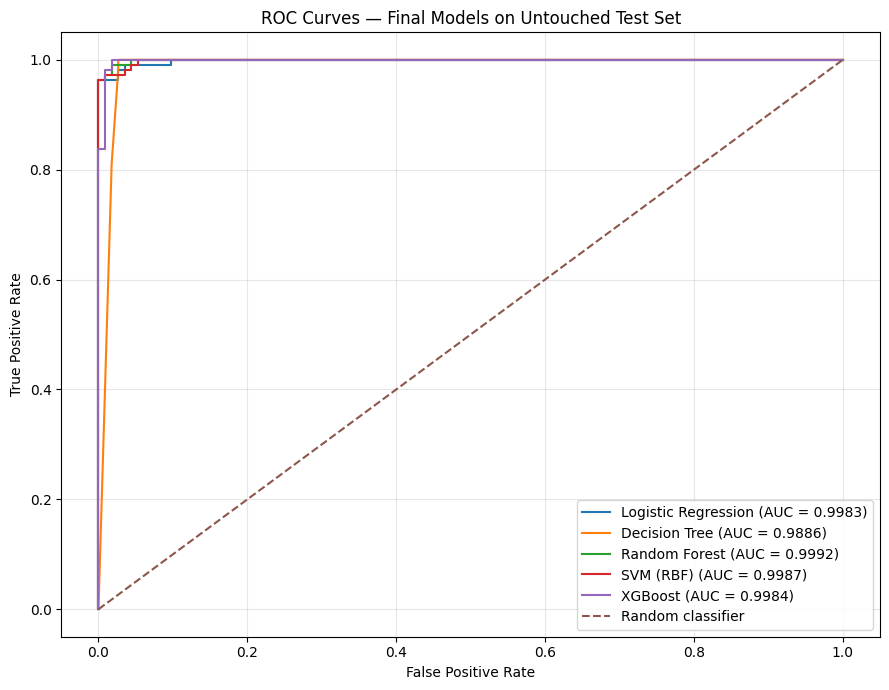

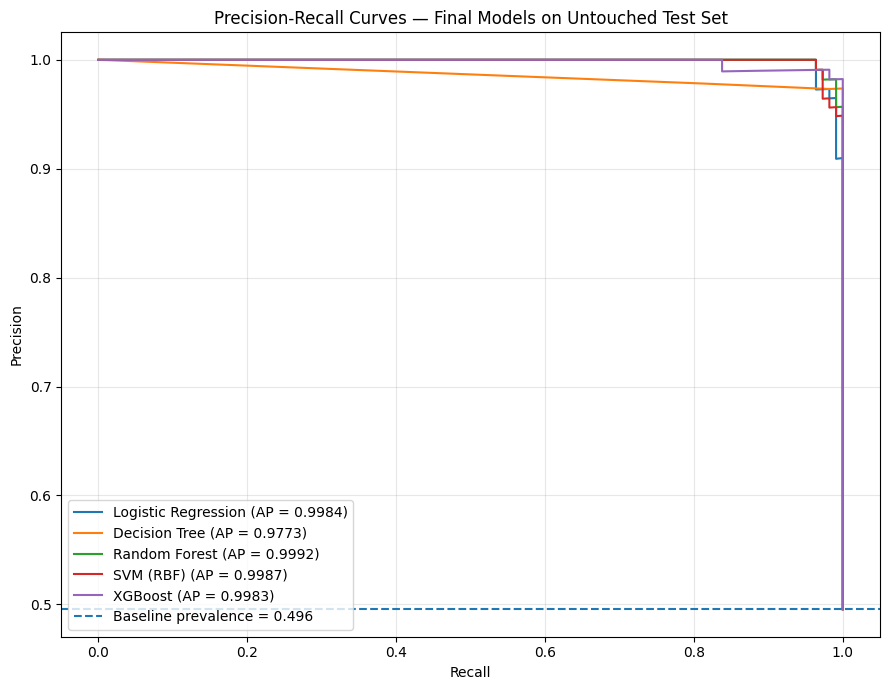

In [ ]:
# ============================================================
# STEP 10 — ROC CURVES + PRECISION-RECALL CURVES
# ============================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)

# ------------------------------------------------------------
# Store model predictions
# ------------------------------------------------------------

model_scores = {
    "Logistic Regression": (y_test, log_score),
    "Decision Tree": (y_test, tree_score),
    "Random Forest": (y_test, rf_score),
    "SVM (RBF)": (y_test, svm_score),
    "XGBoost": (y_test, xgb_score)
}

# ============================================================
# ROC CURVE
# ============================================================

plt.figure(figsize=(9, 7))

for name, (y_true, y_score) in model_scores.items():

    fpr, tpr, _ = roc_curve(
        y_true,
        y_score
    )

    roc_auc_value = auc(
        fpr,
        tpr
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc_value:.4f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curves — Final Models on Untouched Test Set"
)

plt.legend(
    loc="lower right"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

plt.figure(figsize=(9, 7))

for name, (y_true, y_score) in model_scores.items():

    precision, recall, _ = precision_recall_curve(
        y_true,
        y_score
    )

    ap_value = average_precision_score(
        y_true,
        y_score
    )

    plt.plot(
        recall,
        precision,
        label=f"{name} (AP = {ap_value:.4f})"
    )

# Positive-class prevalence baseline
baseline = y_test.mean()

plt.axhline(
    baseline,
    linestyle="--",
    label=f"Baseline prevalence = {baseline:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.title(
    "Precision-Recall Curves — Final Models on Untouched Test Set"
)

plt.legend(
    loc="lower left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

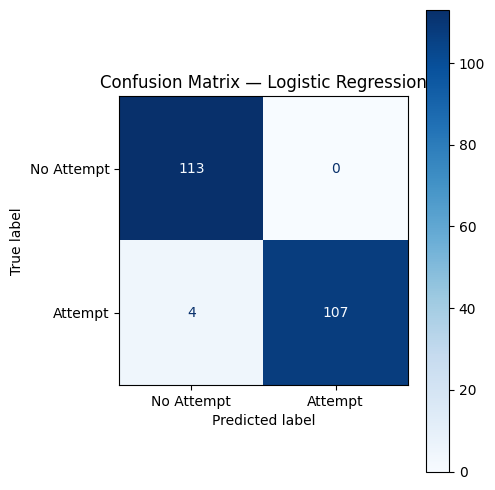

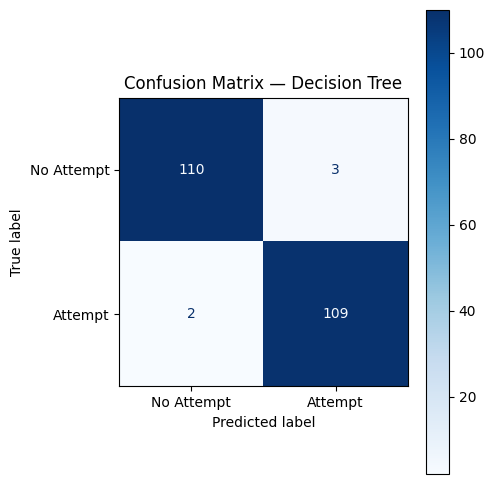

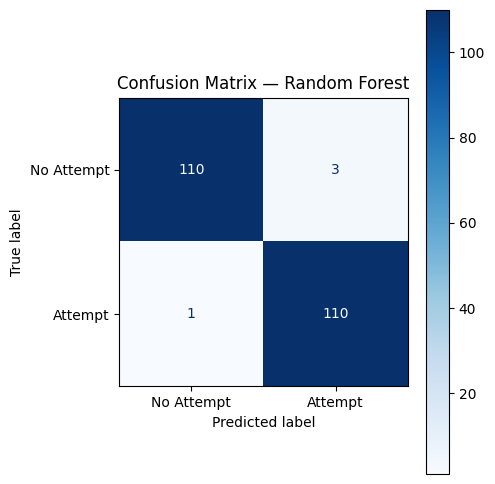

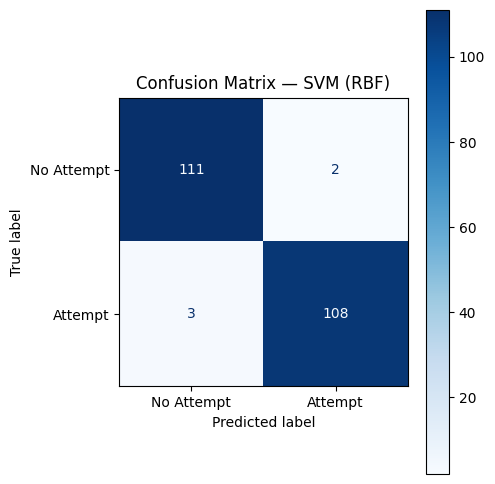

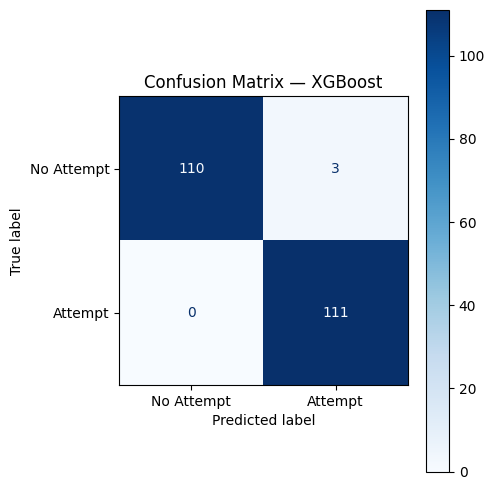

In [ ]:
# ============================================================
# STEP 11 — CONFUSION MATRICES
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

final_predictions = {
    "Logistic Regression": log_pred,
    "Decision Tree": tree_pred,
    "Random Forest": rf_pred,
    "SVM (RBF)": svm_pred,
    "XGBoost": xgb_pred
}

for name, predictions in final_predictions.items():

    fig, ax = plt.subplots(figsize=(5, 5))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        display_labels=["No Attempt", "Attempt"],
        cmap="Blues",
        values_format="d",
        ax=ax
    )

    ax.set_title(
        f"Confusion Matrix — {name}"
    )

    plt.tight_layout()
    plt.show()

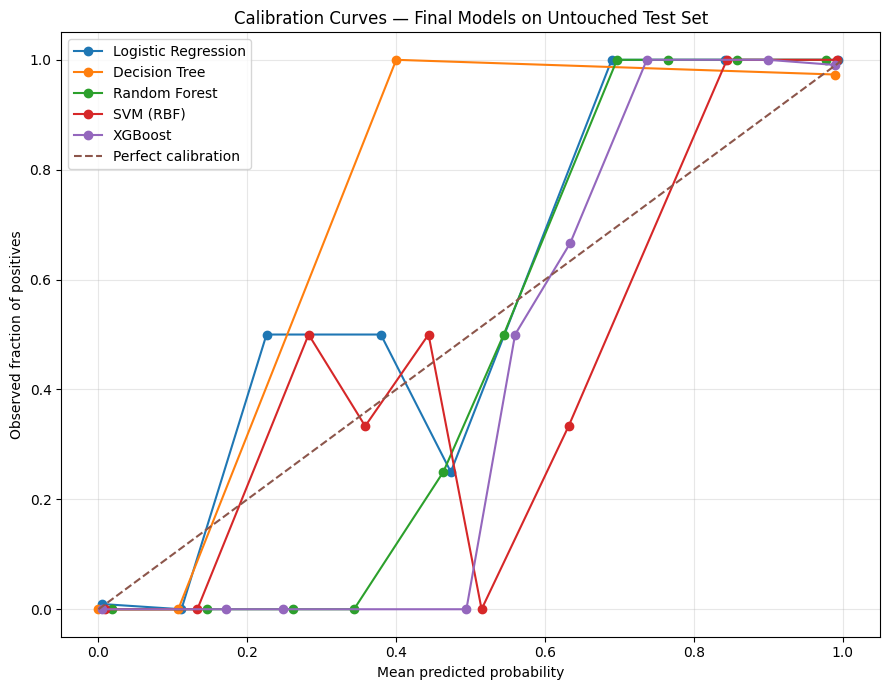

BRIER SCORE — FINAL TEST SET
Logistic Regression      : 0.0147
Decision Tree            : 0.0169
Random Forest            : 0.0193
SVM (RBF)                : 0.0143
XGBoost                  : 0.0122

CALIBRATION INTERCEPT AND SLOPE


,Model,Calibration_Intercept,Calibration_Slope
0,Logistic Regression,0.4918,1.2362
1,Decision Tree,0.0445,0.3945
2,Random Forest,-0.6439,4.4049
3,SVM (RBF),-0.2173,1.6447
4,XGBoost,-0.6195,1.3755


In [ ]:
# ============================================================
# STEP 12 — CALIBRATION ANALYSIS
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression


# ------------------------------------------------------------
# Store probability predictions
# ------------------------------------------------------------

probability_predictions = {
    "Logistic Regression": log_score,
    "Decision Tree": tree_score,
    "Random Forest": rf_score,
    "SVM (RBF)": svm_score,
    "XGBoost": xgb_score
}


# ============================================================
# CALIBRATION CURVE
# ============================================================

plt.figure(figsize=(9, 7))

for name, probabilities in probability_predictions.items():

    fraction_positive, mean_predicted_value = calibration_curve(
        y_test,
        probabilities,
        n_bins=10,
        strategy="uniform"
    )

    plt.plot(
        mean_predicted_value,
        fraction_positive,
        marker="o",
        label=name
    )


# Perfect calibration reference
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction of positives")

plt.title(
    "Calibration Curves — Final Models on Untouched Test Set"
)

plt.legend(
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# BRIER SCORE
# ============================================================

print("=" * 70)
print("BRIER SCORE — FINAL TEST SET")
print("=" * 70)

for name, probabilities in probability_predictions.items():

    brier = brier_score_loss(
        y_test,
        probabilities
    )

    print(
        f"{name:25s}: {brier:.4f}"
    )


# ============================================================
# CALIBRATION INTERCEPT + SLOPE
# ============================================================

print("\n" + "=" * 70)
print("CALIBRATION INTERCEPT AND SLOPE")
print("=" * 70)

calibration_results = []

for name, probabilities in probability_predictions.items():

    # Avoid log(0) and log(1)
    p = np.clip(
        probabilities,
        1e-6,
        1 - 1e-6
    )

    # Logit of predicted probability
    logit_p = np.log(
        p / (1 - p)
    ).reshape(-1, 1)

    calibration_model = LogisticRegression(
        C=1e6,
        max_iter=2000
    )

    calibration_model.fit(
        logit_p,
        y_test
    )

    intercept = calibration_model.intercept_[0]
    slope = calibration_model.coef_[0][0]

    calibration_results.append({
        "Model": name,
        "Calibration_Intercept": intercept,
        "Calibration_Slope": slope
    })

calibration_df = pd.DataFrame(
    calibration_results
).round(4)

display(calibration_df)

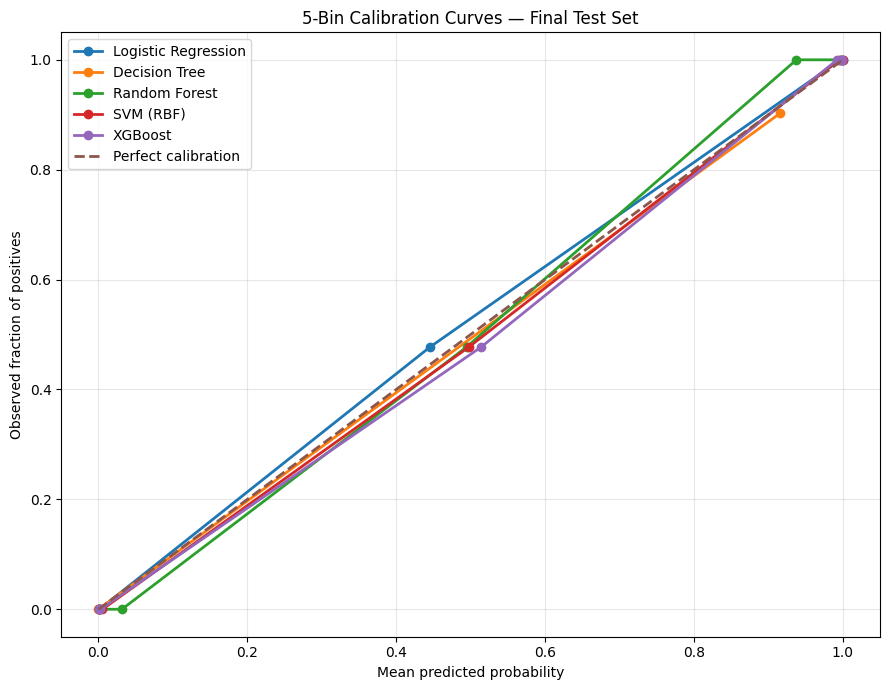

In [ ]:
# ============================================================
# STEP 12A — 5-BIN CALIBRATION CURVE
# ============================================================

import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

plt.figure(figsize=(9, 7))

for name, probabilities in probability_predictions.items():

    fraction_positive, mean_predicted = calibration_curve(
        y_test,
        probabilities,
        n_bins=5,
        strategy="quantile"
    )

    plt.plot(
        mean_predicted,
        fraction_positive,
        marker="o",
        linewidth=2,
        label=name
    )

# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=2,
    label="Perfect calibration"
)

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed fraction of positives")

plt.title(
    "5-Bin Calibration Curves — Final Test Set"
)

plt.legend(
    loc="upper left"
)

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

In [ ]:
# ============================================================
# STEP 13A — SHAP SETUP
# ============================================================

!pip -q install shap

import shap
import numpy as np
import pandas as pd

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [ ]:
# ============================================================
# STEP 13B — XGBOOST SHAP EXPLAINABILITY
# ============================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Create SHAP explainer
# ------------------------------------------------------------

explainer = shap.TreeExplainer(
    final_xgb
)

# Calculate SHAP values on untouched test set
shap_values = explainer(
    X_test_xgb
)

print("SHAP calculation completed.")

print("\nSHAP values shape:")
print(shap_values.values.shape)

print("\nTest data shape:")
print(X_test_xgb.shape)

print("\nExpected value / base value:")
print(explainer.expected_value)

SHAP calculation completed.

SHAP values shape:
(224, 81)

Test data shape:
(224, 81)

Expected value / base value:
-0.033244208


TOP 15 FEATURES — GLOBAL SHAP IMPORTANCE


,Feature,Mean_Absolute_SHAP
0,Alcohol__No,2.67681
1,Sad/ Weary__0.0,1.24442
2,Alcohol__Unknown/Not reported,0.76669
3,Anger__No,0.64702
4,Isolation__No,0.41127
5,Sleep Problem__No,0.31923
6,Religion__Islam,0.29718
7,Occupation_Standard__Unemployed persons,0.29240
8,Occupation_Standard__Student,0.21964
9,Psych Session__No,0.21478


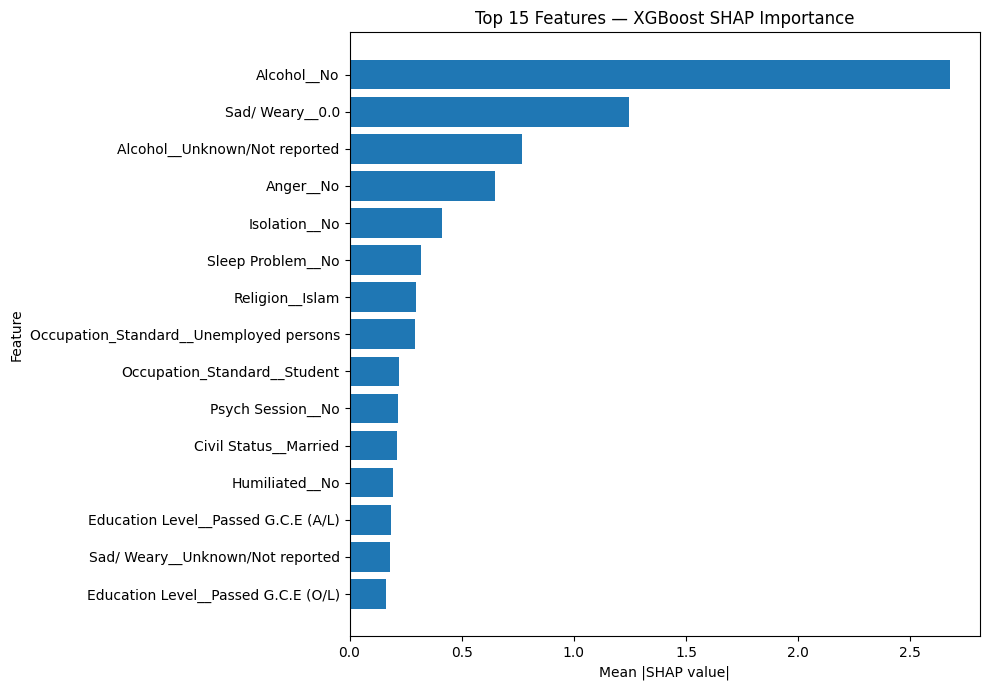

In [ ]:
# ============================================================
# STEP 13C — GLOBAL SHAP FEATURE IMPORTANCE
# ============================================================

# Mean absolute SHAP value
mean_abs_shap = np.abs(
    shap_values.values
).mean(axis=0)

# Create importance table
shap_importance = pd.DataFrame({
    "Feature": X_test_xgb.columns,
    "Mean_Absolute_SHAP": mean_abs_shap
})

# Sort descending
shap_importance = shap_importance.sort_values(
    "Mean_Absolute_SHAP",
    ascending=False
).reset_index(drop=True)

# Top 15
top_15_shap = shap_importance.head(15)

print("=" * 70)
print("TOP 15 FEATURES — GLOBAL SHAP IMPORTANCE")
print("=" * 70)

display(
    top_15_shap.round(5)
)


# ============================================================
# BAR PLOT
# ============================================================

plt.figure(figsize=(10, 7))

plt.barh(
    top_15_shap["Feature"][::-1],
    top_15_shap["Mean_Absolute_SHAP"][::-1]
)

plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")

plt.title(
    "Top 15 Features — XGBoost SHAP Importance"
)

plt.tight_layout()

plt.show()

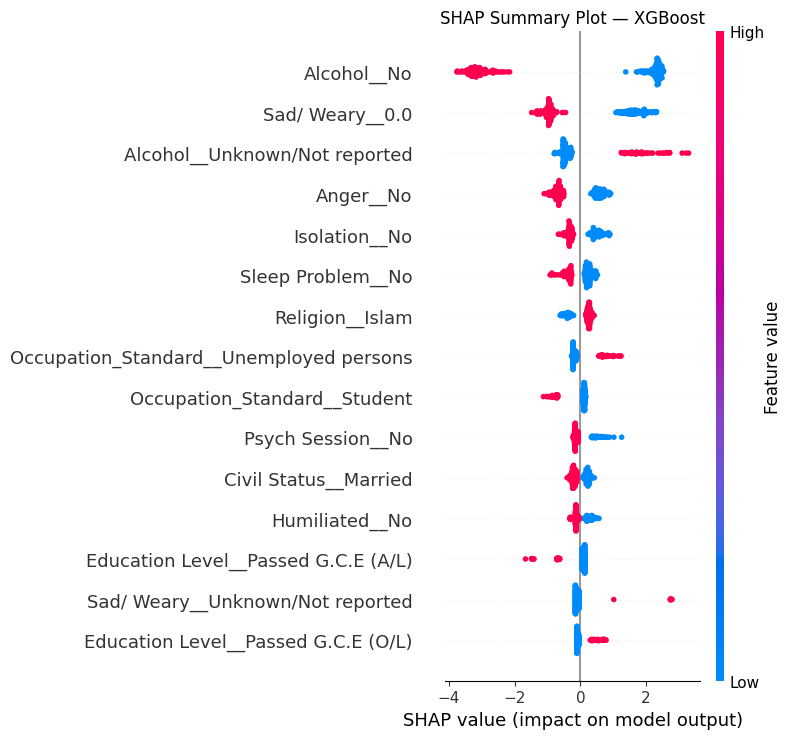

In [ ]:
# ============================================================
# STEP 13D — SHAP BEESWARM / SUMMARY PLOT
# ============================================================

plt.figure(figsize=(10, 8))

shap.summary_plot(
    shap_values.values,
    X_test_xgb,
    max_display=15,
    show=False
)

plt.title(
    "SHAP Summary Plot — XGBoost"
)

plt.tight_layout()

plt.show()

GROUPED SHAP IMPORTANCE — ORIGINAL VARIABLES


,Original_Variable,Mean_Absolute_SHAP
0,Alcohol,3.59996
1,Sad/ Weary,1.50161
2,Anger,0.76858
3,Occupation_Standard,0.73569
4,Education Level,0.64622
5,Isolation,0.46083
6,Religion,0.45141
7,Sleep Problem,0.42625
8,Civil Status,0.36445
9,Psych Session,0.26072


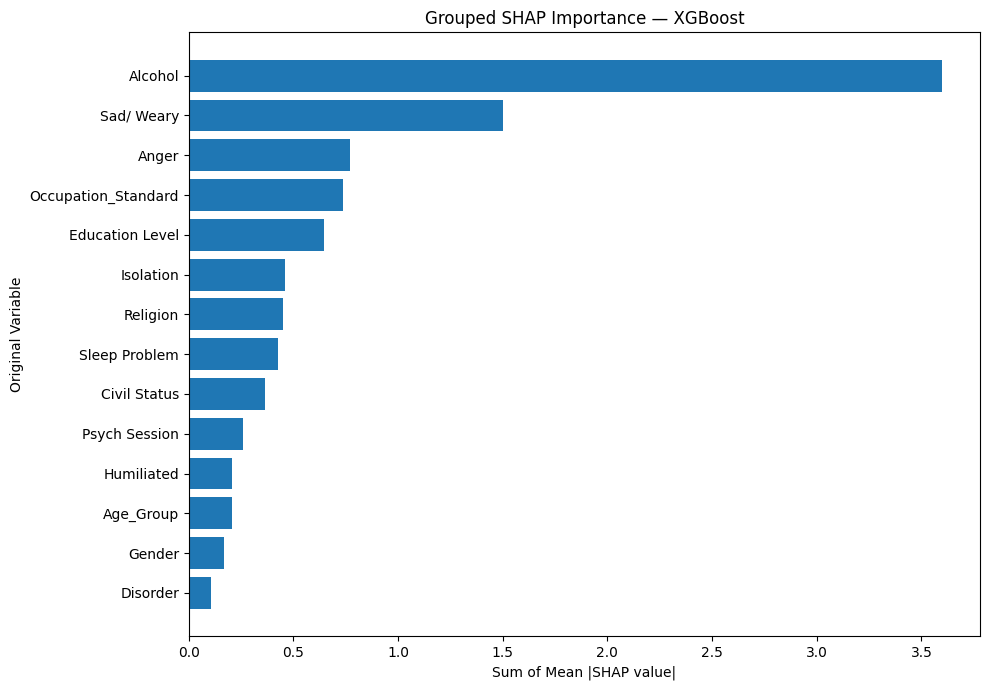

In [ ]:
# ============================================================
# STEP 13E — GROUP SHAP BY ORIGINAL VARIABLE
# ============================================================

# Create SHAP importance dataframe
grouped_shap = pd.DataFrame({
    "Encoded_Feature": X_test_xgb.columns,
    "Mean_Absolute_SHAP": np.abs(
        shap_values.values
    ).mean(axis=0)
})


# ------------------------------------------------------------
# Function to recover original variable name
# ------------------------------------------------------------

def get_original_variable(feature):

    # Everything before the "__" separator
    if "__" in feature:
        return feature.split("__")[0]

    return feature


grouped_shap["Original_Variable"] = (
    grouped_shap["Encoded_Feature"]
    .apply(get_original_variable)
)


# ------------------------------------------------------------
# Aggregate SHAP importance
# ------------------------------------------------------------

grouped_importance = (
    grouped_shap
    .groupby("Original_Variable")[
        "Mean_Absolute_SHAP"
    ]
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)


print("=" * 70)
print("GROUPED SHAP IMPORTANCE — ORIGINAL VARIABLES")
print("=" * 70)

display(
    grouped_importance.round(5)
)


# ============================================================
# TOP 15 GROUPED SHAP VARIABLES
# ============================================================

top_grouped = grouped_importance.head(15)


plt.figure(figsize=(10, 7))

plt.barh(
    top_grouped["Original_Variable"][::-1],
    top_grouped["Mean_Absolute_SHAP"][::-1]
)

plt.xlabel("Sum of Mean |SHAP value|")
plt.ylabel("Original Variable")

plt.title(
    "Grouped SHAP Importance — XGBoost"
)

plt.tight_layout()

plt.show()

TOP 5 SHAP FEATURES
1. Alcohol__No
2. Sad/ Weary__0.0
3. Alcohol__Unknown/Not reported
4. Anger__No
5. Isolation__No


<Figure size 800x600 with 0 Axes>

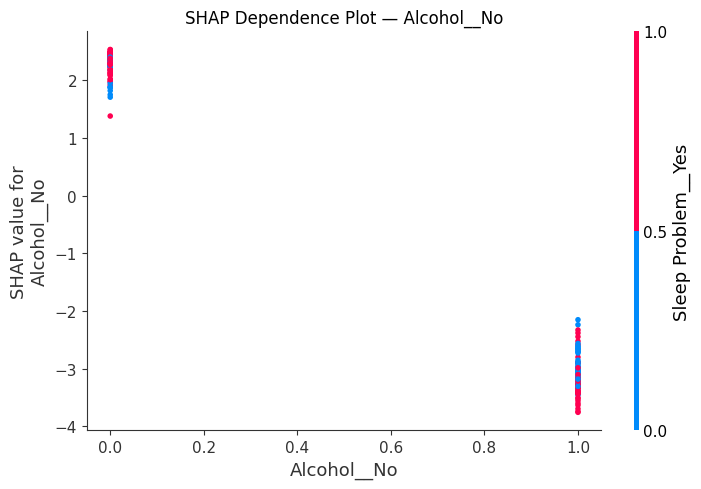

<Figure size 800x600 with 0 Axes>

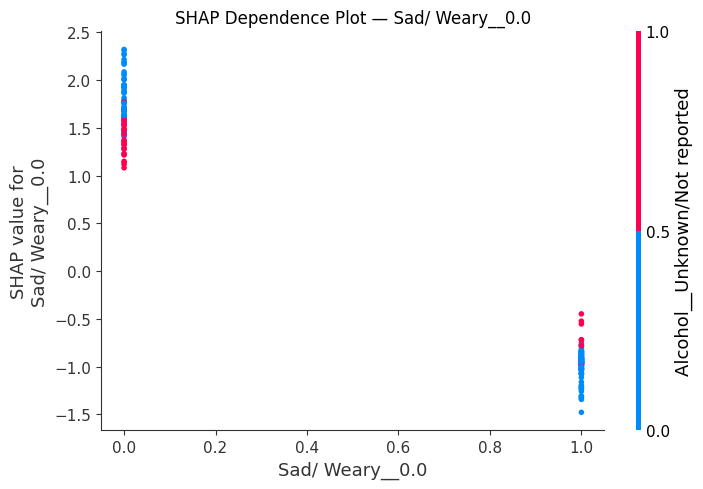

<Figure size 800x600 with 0 Axes>

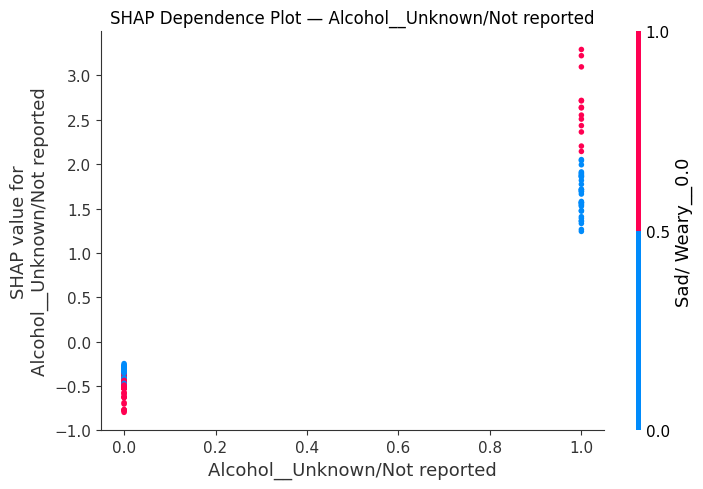

<Figure size 800x600 with 0 Axes>

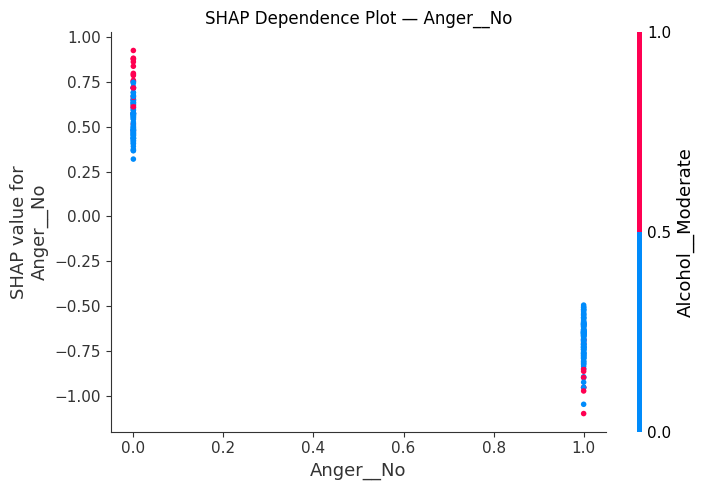

<Figure size 800x600 with 0 Axes>

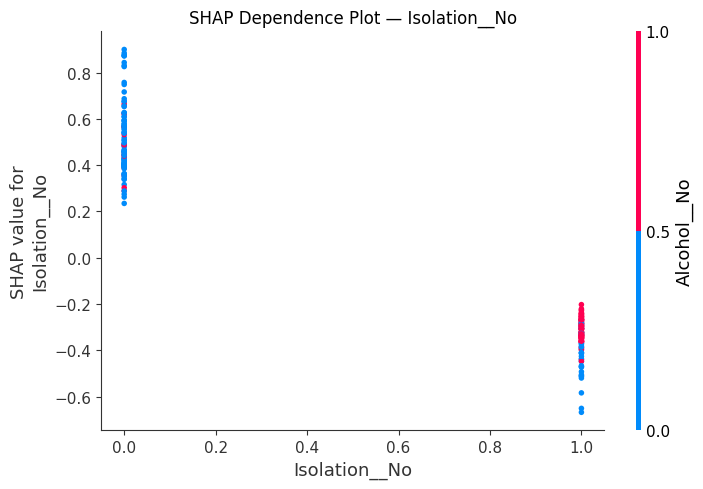

In [ ]:
# ============================================================
# STEP 13F — SHAP DEPENDENCE PLOTS
# ============================================================

top_features = top_15_shap["Feature"].head(5).tolist()

print("=" * 70)
print("TOP 5 SHAP FEATURES")
print("=" * 70)

for i, feature in enumerate(top_features, start=1):
    print(f"{i}. {feature}")


# ------------------------------------------------------------
# Create dependence plots
# ------------------------------------------------------------

for feature in top_features:

    plt.figure(figsize=(8, 6))

    shap.dependence_plot(
        feature,
        shap_values.values,
        X_test_xgb,
        interaction_index="auto",
        show=False
    )

    plt.title(
        f"SHAP Dependence Plot — {feature}"
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# STEP 13G — SHAP INTERACTION ANALYSIS
# ============================================================

print("=" * 70)
print("SHAP INTERACTION ANALYSIS")
print("=" * 70)

# Calculate SHAP interaction values
explainer = shap.TreeExplainer(final_xgb)

shap_interaction_values = explainer.shap_interaction_values(
    X_test_xgb
)

print("Interaction SHAP shape:")
print(np.array(shap_interaction_values).shape)

print("\nInteraction values calculated successfully.")

SHAP INTERACTION ANALYSIS
Interaction SHAP shape:
(224, 81, 81)

Interaction values calculated successfully.


In [ ]:
# ============================================================
# STEP 13H — TOP SHAP FEATURE INTERACTIONS
# ============================================================

interaction_values = np.array(shap_interaction_values)

feature_names = X_test_xgb.columns.tolist()

# Mean absolute interaction strength
mean_abs_interaction = np.abs(interaction_values).mean(axis=0)

# Remove self-interactions from consideration
np.fill_diagonal(mean_abs_interaction, 0)

# Get upper triangle only to avoid duplicate pairs
upper_triangle = np.triu(mean_abs_interaction, k=1)

# Find top 15 interaction pairs
interaction_indices = np.argsort(
    upper_triangle.ravel()
)[::-1]

top_interactions = []

for idx in interaction_indices:

    i, j = np.unravel_index(
        idx,
        upper_triangle.shape
    )

    value = upper_triangle[i, j]

    if value > 0:

        top_interactions.append({
            "Feature 1": feature_names[i],
            "Feature 2": feature_names[j],
            "Mean |SHAP Interaction|": value
        })

    if len(top_interactions) == 15:
        break

top_interactions_df = pd.DataFrame(top_interactions)

print("=" * 80)
print("TOP 15 SHAP FEATURE INTERACTIONS")
print("=" * 80)

display(
    top_interactions_df.style.format({
        "Mean |SHAP Interaction|": "{:.4f}"
    })
)

TOP 15 SHAP FEATURE INTERACTIONS


,Feature 1,Feature 2,Mean |SHAP Interaction|
0,Alcohol__No,Sad/ Weary__0.0,0.1049
1,Alcohol__Unknown/Not reported,Sad/ Weary__0.0,0.1044
2,Alcohol__No,Alcohol__Unknown/Not reported,0.0933
3,Alcohol__No,Sad/ Weary__Unknown/Not reported,0.0763
4,Alcohol__No,Anger__No,0.0690
5,Alcohol__Frequent,Sleep Problem__No,0.0646
6,Education Level__Passed G.C.E (A/L),Alcohol__No,0.0614
7,Humiliated__No,Sad/ Weary__0.0,0.0597
8,Alcohol__No,Isolation__No,0.0567
9,Alcohol__No,Sleep Problem__No,0.0515


In [ ]:
# ============================================================
# STEP 13I — ORIGINAL FEATURE-LEVEL SHAP INTERACTIONS
# ============================================================

# Convert encoded feature names back to original feature names
def get_original_feature(feature_name):
    return feature_name.split("__")[0]

original_features = [
    get_original_feature(col)
    for col in feature_names
]

unique_original_features = sorted(set(original_features))

grouped_interactions = []

for i, feature_a in enumerate(unique_original_features):

    for feature_b in unique_original_features[i + 1:]:

        # Find encoded columns belonging to each original feature
        cols_a = [
            k for k, name in enumerate(original_features)
            if name == feature_a
        ]

        cols_b = [
            k for k, name in enumerate(original_features)
            if name == feature_b
        ]

        # Aggregate absolute interaction values
        interaction_strength = np.abs(
            interaction_values[:, cols_a][:, :, cols_b]
        ).mean()

        grouped_interactions.append({
            "Feature 1": feature_a,
            "Feature 2": feature_b,
            "Mean |SHAP Interaction|": interaction_strength
        })

grouped_interactions_df = pd.DataFrame(
    grouped_interactions
).sort_values(
    "Mean |SHAP Interaction|",
    ascending=False
).head(15)

print("=" * 80)
print("TOP 15 ORIGINAL-FEATURE SHAP INTERACTIONS")
print("=" * 80)

display(
    grouped_interactions_df.style.format({
        "Mean |SHAP Interaction|": "{:.4f}"
    })
)

TOP 15 ORIGINAL-FEATURE SHAP INTERACTIONS


,Feature 1,Feature 2,Mean |SHAP Interaction|
23,Alcohol,Sad/ Weary,0.0250
24,Alcohol,Sleep Problem,0.0199
13,Alcohol,Anger,0.0192
74,Humiliated,Sad/ Weary,0.0124
18,Alcohol,Humiliated,0.0087
30,Anger,Isolation,0.0082
34,Anger,Sad/ Weary,0.0076
79,Isolation,Sad/ Weary,0.0073
19,Alcohol,Isolation,0.0068
80,Isolation,Sleep Problem,0.0065


In [ ]:
# ============================================================
# STEP 14A — FINAL MODEL COMPARISON TABLE
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# CROSS-VALIDATION RESULTS
# ------------------------------------------------------------

cv_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],

    "CV Accuracy": [
        "0.9855 ± 0.0109",
        "0.9654 ± 0.0178",
        "0.9810 ± 0.0104",
        "0.9732 ± 0.0096",
        "0.9832 ± 0.0106"
    ],

    "CV Precision": [
        "0.9781 ± 0.0192",
        "0.9547 ± 0.0303",
        "0.9780 ± 0.0193",
        "0.9775 ± 0.0118",
        "0.9802 ± 0.0184"
    ],

    "CV Recall": [
        "0.9932 ± 0.0055",
        "0.9774 ± 0.0101",
        "0.9842 ± 0.0055",
        "0.9684 ± 0.0193",
        "0.9865 ± 0.0085"
    ],

    "CV Specificity": [
        "0.9779 ± 0.0198",
        "0.9536 ± 0.0325",
        "0.9779 ± 0.0198",
        "0.9779 ± 0.0122",
        "0.9801 ± 0.0191"
    ],

    "CV F1": [
        "0.9855 ± 0.0107",
        "0.9657 ± 0.0171",
        "0.9810 ± 0.0102",
        "0.9728 ± 0.0099",
        "0.9832 ± 0.0104"
    ],

    "CV ROC-AUC": [
        "0.9989 ± 0.0008",
        "0.9734 ± 0.0201",
        "0.9988 ± 0.0010",
        "0.9984 ± 0.0008",
        "0.9985 ± 0.0010"
    ],

    "CV AP": [
        "0.9989 ± 0.0008",
        "0.9567 ± 0.0331",
        "0.9988 ± 0.0011",
        "0.9984 ± 0.0007",
        "0.9984 ± 0.0010"
    ]
})


# ------------------------------------------------------------
# FINAL TEST-SET RESULTS
# ------------------------------------------------------------

test_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],

    "Test Accuracy": [
        0.9821,
        0.9777,
        0.9821,
        0.9777,
        0.9866
    ],

    "Test Precision": [
        1.0000,
        0.9732,
        0.9735,
        0.9818,
        0.9737
    ],

    "Test Recall": [
        0.9640,
        0.9820,
        0.9910,
        0.9730,
        1.0000
    ],

    "Test Specificity": [
        1.0000,
        0.9735,
        0.9735,
        0.9823,
        0.9735
    ],

    "Test F1": [
        0.9817,
        0.9776,
        0.9821,
        0.9774,
        0.9867
    ],

    "Test ROC-AUC": [
        0.9983,
        0.9886,
        0.9992,
        0.9987,
        0.9984
    ],

    "Test AP": [
        0.9984,
        0.9773,
        0.9992,
        0.9987,
        0.9983
    ]
})


# ------------------------------------------------------------
# DISPLAY CV RESULTS
# ------------------------------------------------------------

print("=" * 100)
print("CROSS-VALIDATION PERFORMANCE")
print("=" * 100)

display(cv_results)


# ------------------------------------------------------------
# DISPLAY TEST RESULTS
# ------------------------------------------------------------

print("\n")
print("=" * 100)
print("FINAL UNTOUCHED TEST-SET PERFORMANCE")
print("=" * 100)

display(
    test_results.style.format({
        "Test Accuracy": "{:.4f}",
        "Test Precision": "{:.4f}",
        "Test Recall": "{:.4f}",
        "Test Specificity": "{:.4f}",
        "Test F1": "{:.4f}",
        "Test ROC-AUC": "{:.4f}",
        "Test AP": "{:.4f}"
    })
)

CROSS-VALIDATION PERFORMANCE


,Model,CV Accuracy,CV Precision,CV Recall,CV Specificity,CV F1,CV ROC-AUC,CV AP
0,Logistic Regression,0.9855 ± 0.0109,0.9781 ± 0.0192,0.9932 ± 0.0055,0.9779 ± 0.0198,0.9855 ± 0.0107,0.9989 ± 0.0008,0.9989 ± 0.0008
1,Decision Tree,0.9654 ± 0.0178,0.9547 ± 0.0303,0.9774 ± 0.0101,0.9536 ± 0.0325,0.9657 ± 0.0171,0.9734 ± 0.0201,0.9567 ± 0.0331
2,Random Forest,0.9810 ± 0.0104,0.9780 ± 0.0193,0.9842 ± 0.0055,0.9779 ± 0.0198,0.9810 ± 0.0102,0.9988 ± 0.0010,0.9988 ± 0.0011
3,SVM,0.9732 ± 0.0096,0.9775 ± 0.0118,0.9684 ± 0.0193,0.9779 ± 0.0122,0.9728 ± 0.0099,0.9984 ± 0.0008,0.9984 ± 0.0007
4,XGBoost,0.9832 ± 0.0106,0.9802 ± 0.0184,0.9865 ± 0.0085,0.9801 ± 0.0191,0.9832 ± 0.0104,0.9985 ± 0.0010,0.9984 ± 0.0010




FINAL UNTOUCHED TEST-SET PERFORMANCE


,Model,Test Accuracy,Test Precision,Test Recall,Test Specificity,Test F1,Test ROC-AUC,Test AP
0,Logistic Regression,0.9821,1.0000,0.9640,1.0000,0.9817,0.9983,0.9984
1,Decision Tree,0.9777,0.9732,0.9820,0.9735,0.9776,0.9886,0.9773
2,Random Forest,0.9821,0.9735,0.9910,0.9735,0.9821,0.9992,0.9992
3,SVM,0.9777,0.9818,0.9730,0.9823,0.9774,0.9987,0.9987
4,XGBoost,0.9866,0.9737,1.0000,0.9735,0.9867,0.9984,0.9983


In [ ]:
# ============================================================
# STEP 14B — CONFUSION MATRIX SUMMARY
# ============================================================

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Predictions already generated during final test evaluation
# ------------------------------------------------------------

model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}

confusion_matrices = {}

print("=" * 70)
print("CONFUSION MATRIX SUMMARY")
print("=" * 70)

for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    confusion_matrices[model_name] = cm

    tn, fp, fn, tp = cm.ravel()

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"TN = {tn}")
    print(f"FP = {fp}")
    print(f"FN = {fn}")
    print(f"TP = {tp}")

NameError: name 'y_pred_lr' is not defined

In [ ]:
# ============================================================
# STEP 14B — CONFUSION MATRIX SUMMARY
# ============================================================

from sklearn.metrics import confusion_matrix

# Generate predictions from the final fitted models
y_pred_lr = final_lr.predict(X_test)

y_pred_dt = final_dt.predict(X_test)

y_pred_rf = final_rf.predict(X_test)

y_pred_svm = final_svm.predict(X_test)

y_pred_xgb = final_xgb.predict(X_test_xgb)


# Store predictions
model_predictions = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm,
    "XGBoost": y_pred_xgb
}


# Calculate and display confusion matrices
confusion_matrices = {}

print("=" * 70)
print("CONFUSION MATRIX SUMMARY")
print("=" * 70)

for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    confusion_matrices[model_name] = cm

    tn, fp, fn, tp = cm.ravel()

    print(f"\n{model_name}")
    print("-" * 40)
    print(f"TN = {tn}")
    print(f"FP = {fp}")
    print(f"FN = {fn}")
    print(f"TP = {tp}")
    print(f"Confusion Matrix = {cm.tolist()}")

NameError: name 'final_lr' is not defined

In [ ]:
# ============================================================
# STEP 14B — FINAL CONFUSION MATRIX DATA
# Self-contained version
# ============================================================

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from xgboost import XGBClassifier

import numpy as np


# ------------------------------------------------------------
# 1. LOGISTIC REGRESSION
# ------------------------------------------------------------

lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)
pred_lr = lr_model.predict(X_test)


# ------------------------------------------------------------
# 2. DECISION TREE
# ------------------------------------------------------------

dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)
pred_dt = dt_model.predict(X_test)


# ------------------------------------------------------------
# 3. RANDOM FOREST
# ------------------------------------------------------------

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)


# ------------------------------------------------------------
# 4. SVM
# ------------------------------------------------------------

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)
pred_svm = svm_model.predict(X_test)


# ------------------------------------------------------------
# 5. XGBOOST
# ------------------------------------------------------------

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train)
pred_xgb = xgb_model.predict(X_test_xgb)


# ------------------------------------------------------------
# 6. STORE PREDICTIONS
# ------------------------------------------------------------

model_predictions = {
    "Logistic Regression": pred_lr,
    "Decision Tree": pred_dt,
    "Random Forest": pred_rf,
    "SVM": pred_svm,
    "XGBoost": pred_xgb
}


# ------------------------------------------------------------
# 7. CONFUSION MATRICES
# ------------------------------------------------------------

confusion_matrices = {}

print("=" * 75)
print("FINAL CONFUSION MATRIX SUMMARY")
print("=" * 75)

for model_name, predictions in model_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    confusion_matrices[model_name] = cm

    tn, fp, fn, tp = cm.ravel()

    print(f"\n{model_name}")
    print("-" * 45)
    print(f"TN = {tn}")
    print(f"FP = {fp}")
    print(f"FN = {fn}")
    print(f"TP = {tp}")
    print(f"Matrix = {cm.tolist()}")

FINAL CONFUSION MATRIX SUMMARY

Logistic Regression
---------------------------------------------
TN = 113
FP = 0
FN = 4
TP = 107
Matrix = [[113, 0], [4, 107]]

Decision Tree
---------------------------------------------
TN = 110
FP = 3
FN = 2
TP = 109
Matrix = [[110, 3], [2, 109]]

Random Forest
---------------------------------------------
TN = 110
FP = 3
FN = 1
TP = 110
Matrix = [[110, 3], [1, 110]]

SVM
---------------------------------------------
TN = 111
FP = 2
FN = 3
TP = 108
Matrix = [[111, 2], [3, 108]]

XGBoost
---------------------------------------------
TN = 110
FP = 3
FN = 0
TP = 111
Matrix = [[110, 3], [0, 111]]


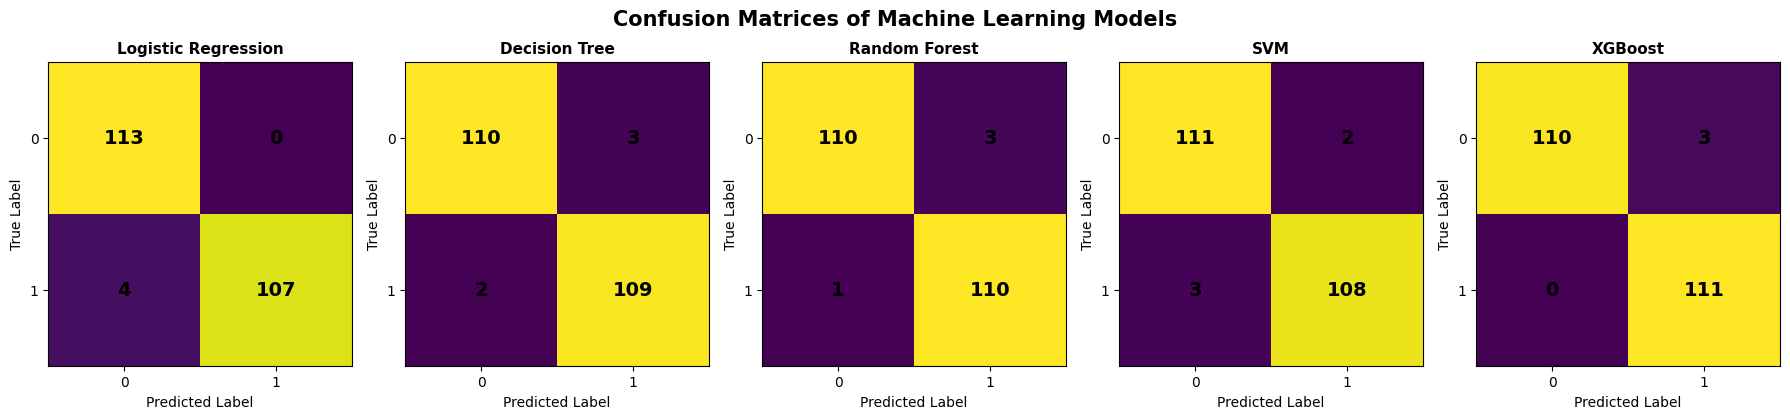

In [ ]:
# ============================================================
# STEP 14C — COMBINED CONFUSION MATRIX FIGURE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

model_order = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost"
]

fig, axes = plt.subplots(
    1, 5,
    figsize=(18, 4)
)

for ax, model_name in zip(axes, model_order):

    cm = confusion_matrices[model_name]

    im = ax.imshow(cm)

    ax.set_title(
        model_name,
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])

    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])

    # Add values inside cells
    for i in range(2):
        for j in range(2):

            ax.text(
                j,
                i,
                str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=14,
                fontweight="bold"
            )

fig.suptitle(
    "Confusion Matrices of Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "confusion_matrices_all_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

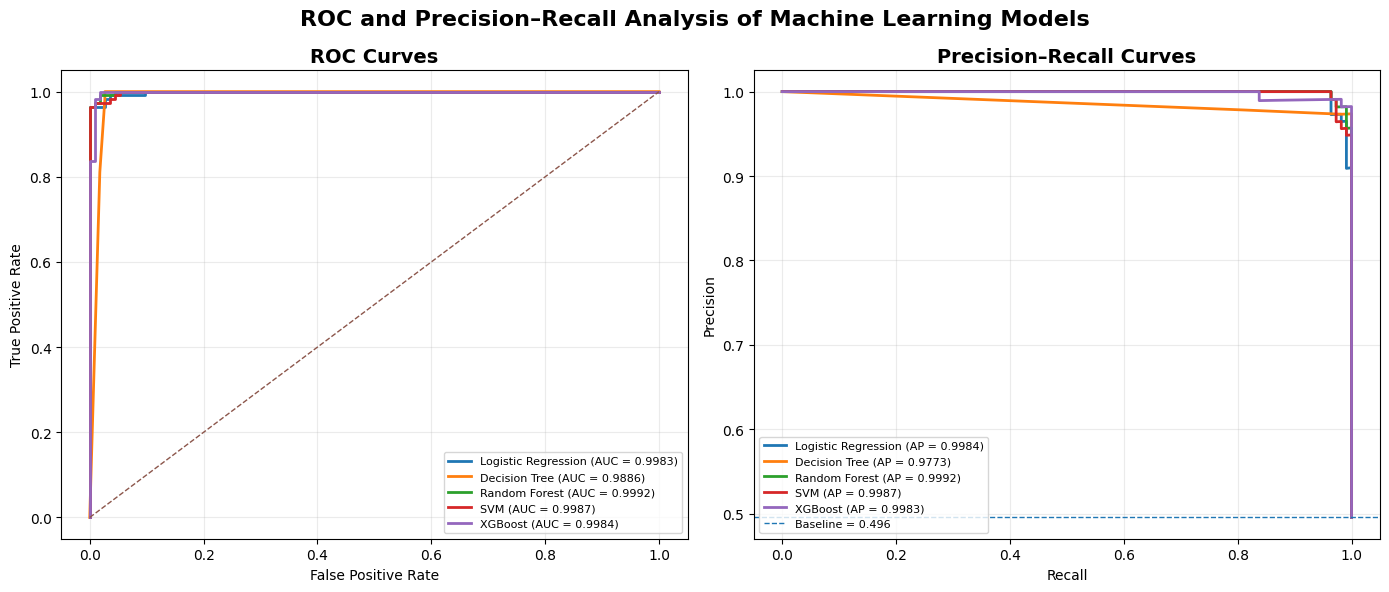

In [ ]:
# ============================================================
# STEP 14D — ROC & PRECISION-RECALL CURVES
# ============================================================

from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    roc_auc_score,
    average_precision_score
)

# ------------------------------------------------------------
# Store probability predictions
# ------------------------------------------------------------

probability_predictions = {
    "Logistic Regression": lr_model.predict_proba(X_test)[:, 1],
    "Decision Tree": dt_model.predict_proba(X_test)[:, 1],
    "Random Forest": rf_model.predict_proba(X_test)[:, 1],
    "SVM": svm_model.predict_proba(X_test)[:, 1],
    "XGBoost": xgb_model.predict_proba(X_test_xgb)[:, 1]
}


# ------------------------------------------------------------
# Create two-panel figure
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6)
)


# ============================================================
# ROC CURVE
# ============================================================

ax = axes[0]

for model_name, probabilities in probability_predictions.items():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities
    )

    ax.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.4f})"
    )


ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1
)

ax.set_title(
    "ROC Curves",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")

ax.legend(
    fontsize=8,
    loc="lower right"
)

ax.grid(
    alpha=0.25
)


# ============================================================
# PRECISION-RECALL CURVE
# ============================================================

ax = axes[1]

positive_prevalence = np.mean(y_test)

for model_name, probabilities in probability_predictions.items():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities
    )

    ap_score = average_precision_score(
        y_test,
        probabilities
    )

    ax.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AP = {ap_score:.4f})"
    )


ax.axhline(
    positive_prevalence,
    linestyle="--",
    linewidth=1,
    label=f"Baseline = {positive_prevalence:.3f}"
)

ax.set_title(
    "Precision–Recall Curves",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")

ax.legend(
    fontsize=8,
    loc="lower left"
)

ax.grid(
    alpha=0.25
)


# ============================================================
# FINALIZE FIGURE
# ============================================================

fig.suptitle(
    "ROC and Precision–Recall Analysis of Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "ROC_PR_curves_all_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# STEP 14E — CALIBRATION CURVE
# ============================================================

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fig, ax = plt.subplots(
    figsize=(8, 7)
)

brier_results = {}

for model_name, probabilities in probability_predictions.items():

    # 5-bin quantile calibration
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test,
        probabilities,
        n_bins=5,
        strategy="quantile"
    )

    # Brier score
    brier = brier_score_loss(
        y_test,
        probabilities
    )

    brier_results[model_name] = brier

    ax.plot(
        mean_predicted_value,
        fraction_of_positives,
        marker="o",
        linewidth=2,
        label=f"{model_name} (Brier = {brier:.4f})"
    )


# Perfect calibration line
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration"
)


ax.set_title(
    "Calibration Curves of Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mean Predicted Probability"
)

ax.set_ylabel(
    "Observed Fraction of Positives"
)

ax.legend(
    fontsize=9
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()

plt.savefig(
    "calibration_curves_all_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# BRIER SCORE TABLE
# ------------------------------------------------------------

brier_df = pd.DataFrame({
    "Model": list(brier_results.keys()),
    "Brier Score": list(brier_results.values())
})

print("=" * 60)
print("BRIER SCORES")
print("=" * 60)

display(
    brier_df.style.format({
        "Brier Score": "{:.4f}"
    })
)

NameError: name 'plt' is not defined

In [ ]:
# ============================================================
# STEP 14E — CALIBRATION CURVE
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss


# ------------------------------------------------------------
# Generate probability predictions
# ------------------------------------------------------------

probability_predictions = {
    "Logistic Regression": lr_model.predict_proba(X_test)[:, 1],

    "Decision Tree": dt_model.predict_proba(X_test)[:, 1],

    "Random Forest": rf_model.predict_proba(X_test)[:, 1],

    "SVM": svm_model.predict_proba(X_test)[:, 1],

    "XGBoost": xgb_model.predict_proba(X_test_xgb)[:, 1]
}


# ------------------------------------------------------------
# Calibration curves
# ------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(8, 7)
)

brier_results = {}


for model_name, probabilities in probability_predictions.items():

    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test,
        probabilities,
        n_bins=5,
        strategy="quantile"
    )

    brier = brier_score_loss(
        y_test,
        probabilities
    )

    brier_results[model_name] = brier

    ax.plot(
        mean_predicted_value,
        fraction_of_positives,
        marker="o",
        linewidth=2,
        label=f"{model_name} (Brier = {brier:.4f})"
    )


# ------------------------------------------------------------
# Perfect calibration reference
# ------------------------------------------------------------

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration"
)


# ------------------------------------------------------------
# Formatting
# ------------------------------------------------------------

ax.set_title(
    "Calibration Curves of Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mean Predicted Probability"
)

ax.set_ylabel(
    "Observed Fraction of Positives"
)

ax.legend(
    fontsize=9
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()


# ------------------------------------------------------------
# Save figure
# ------------------------------------------------------------

plt.savefig(
    "calibration_curves_all_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# BRIER SCORE TABLE
# ------------------------------------------------------------

brier_df = pd.DataFrame({
    "Model": list(brier_results.keys()),
    "Brier Score": list(brier_results.values())
})


print("=" * 60)
print("BRIER SCORES")
print("=" * 60)

display(
    brier_df.style.format({
        "Brier Score": "{:.4f}"
    })
)

NameError: name 'lr_model' is not defined

In [ ]:
# ============================================================
# STEP 14E — CALIBRATION CURVE
# SELF-CONTAINED VERSION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

from xgboost import XGBClassifier


# ============================================================
# 1. CREATE AND TRAIN MODELS
# ============================================================

# Logistic Regression
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr_model.fit(X_train, y_train)


# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt_model.fit(X_train, y_train)


# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


# SVM
svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

svm_model.fit(X_train, y_train)


# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb_model.fit(X_train_xgb, y_train)


# ============================================================
# 2. GENERATE PROBABILITY PREDICTIONS
# ============================================================

probability_predictions = {

    "Logistic Regression":
        lr_model.predict_proba(X_test)[:, 1],

    "Decision Tree":
        dt_model.predict_proba(X_test)[:, 1],

    "Random Forest":
        rf_model.predict_proba(X_test)[:, 1],

    "SVM":
        svm_model.predict_proba(X_test)[:, 1],

    "XGBoost":
        xgb_model.predict_proba(X_test_xgb)[:, 1]
}


# ============================================================
# 3. CALIBRATION CURVES
# ============================================================

fig, ax = plt.subplots(
    figsize=(8, 7)
)

brier_results = {}


for model_name, probabilities in probability_predictions.items():

    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test,
        probabilities,
        n_bins=5,
        strategy="quantile"
    )

    brier = brier_score_loss(
        y_test,
        probabilities
    )

    brier_results[model_name] = brier

    ax.plot(
        mean_predicted_value,
        fraction_of_positives,
        marker="o",
        linewidth=2,
        label=f"{model_name} (Brier = {brier:.4f})"
    )


# Perfect calibration
ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1.5,
    label="Perfect calibration"
)


# ============================================================
# 4. FORMAT FIGURE
# ============================================================

ax.set_title(
    "Calibration Curves of Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Mean Predicted Probability"
)

ax.set_ylabel(
    "Observed Fraction of Positives"
)

ax.legend(
    fontsize=9
)

ax.grid(
    alpha=0.25
)

plt.tight_layout()


# ============================================================
# 5. SAVE FIGURE
# ============================================================

plt.savefig(
    "calibration_curves_all_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 6. BRIER SCORE TABLE
# ============================================================

brier_df = pd.DataFrame({
    "Model": list(brier_results.keys()),
    "Brier Score": list(brier_results.values())
})

print("=" * 60)
print("BRIER SCORES")
print("=" * 60)

display(
    brier_df.style.format({
        "Brier Score": "{:.4f}"
    })
)

NameError: name 'X_train' is not defined

In [ ]:
# ============================================================
# STEP 14E — CALIBRATION CURVE + BRIER SCORE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from xgboost import XGBClassifier


# ============================================================
# 1. LOAD MODEL-READY DATA
# ============================================================

df = pd.read_csv("model_ready_reproducible_dataset.csv")

print("Dataset shape:", df.shape)


# ============================================================
# 2. X AND y
# ============================================================

X = df.drop("Attempted?", axis=1)
y = df["Attempted?"]

print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


# ============================================================
# 4. XGBOOST SAFE COLUMN NAMES
# ============================================================

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = (
    X_train_xgb.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
)

X_test_xgb.columns = X_train_xgb.columns


# ============================================================
# 5. LOGISTIC REGRESSION
# ============================================================

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr.fit(X_train, y_train)

prob_lr = lr.predict_proba(X_test)[:, 1]


# ============================================================
# 6. DECISION TREE
# ============================================================

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

prob_dt = dt.predict_proba(X_test)[:, 1]


# ============================================================
# 7. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

prob_rf = rf.predict_proba(X_test)[:, 1]


# ============================================================
# 8. SVM
# ============================================================

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

svm.fit(X_train, y_train)

prob_svm = svm.predict_proba(X_test)[:, 1]


# ============================================================
# 9. XGBOOST
# ============================================================

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb.fit(X_train_xgb, y_train)

prob_xgb = xgb.predict_proba(X_test_xgb)[:, 1]


# ============================================================
# 10. STORE PROBABILITIES
# ============================================================

probabilities = {
    "Logistic Regression": prob_lr,
    "Decision Tree": prob_dt,
    "Random Forest": prob_rf,
    "SVM": prob_svm,
    "XGBoost": prob_xgb
}


# ============================================================
# 11. CALIBRATION CURVE
# ============================================================

plt.figure(figsize=(9, 7))

brier_scores = {}

for model_name, prob in probabilities.items():

    fraction_positive, mean_probability = calibration_curve(
        y_test,
        prob,
        n_bins=5,
        strategy="quantile"
    )

    brier = brier_score_loss(
        y_test,
        prob
    )

    brier_scores[model_name] = brier

    plt.plot(
        mean_probability,
        fraction_positive,
        marker="o",
        linewidth=2,
        label=f"{model_name} (Brier={brier:.4f})"
    )


# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1.5,
    label="Perfect Calibration"
)


# ============================================================
# 12. FORMAT
# ============================================================

plt.title(
    "Calibration Curves of Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraction of Positives")

plt.legend(fontsize=9)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "calibration_curves_all_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. BRIER SCORE TABLE
# ============================================================

brier_df = pd.DataFrame({
    "Model": list(brier_scores.keys()),
    "Brier Score": list(brier_scores.values())
})

print("=" * 60)
print("BRIER SCORE")
print("=" * 60)

display(
    brier_df.style.format({
        "Brier Score": "{:.4f}"
    })
)

FileNotFoundError: [Errno 2] No such file or directory: 'model_ready_reproducible_dataset.csv'

In [ ]:
# ============================================================
# STEP 14E-1 — UPLOAD MODEL-READY DATASET
# ============================================================

from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")

for filename in uploaded.keys():
    print("✓", filename)

Saving model_ready_reproducible_dataset.csv to model_ready_reproducible_dataset.csv

Uploaded files:
✓ model_ready_reproducible_dataset.csv


Dataset shape: (1120, 82)
X shape: (1120, 81)
y shape: (1120,)
X_train: (896, 81)
X_test : (224, 81)


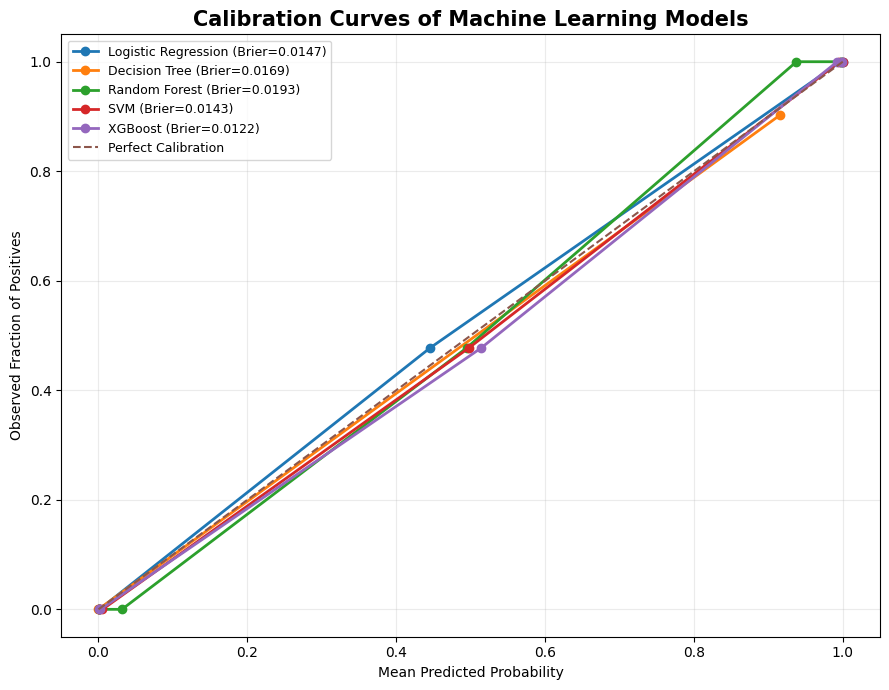

BRIER SCORE


,Model,Brier Score
0,Logistic Regression,0.0147
1,Decision Tree,0.0169
2,Random Forest,0.0193
3,SVM,0.0143
4,XGBoost,0.0122


In [ ]:
# ============================================================
# STEP 14E — CALIBRATION CURVE + BRIER SCORE
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from xgboost import XGBClassifier


# ============================================================
# 1. LOAD MODEL-READY DATA
# ============================================================

df = pd.read_csv("model_ready_reproducible_dataset.csv")

print("Dataset shape:", df.shape)


# ============================================================
# 2. X AND y
# ============================================================

X = df.drop("Attempted?", axis=1)
y = df["Attempted?"]

print("X shape:", X.shape)
print("y shape:", y.shape)


# ============================================================
# 3. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


# ============================================================
# 4. XGBOOST SAFE COLUMN NAMES
# ============================================================

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

X_train_xgb.columns = (
    X_train_xgb.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
)

X_test_xgb.columns = X_train_xgb.columns


# ============================================================
# 5. LOGISTIC REGRESSION
# ============================================================

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

lr.fit(X_train, y_train)

prob_lr = lr.predict_proba(X_test)[:, 1]


# ============================================================
# 6. DECISION TREE
# ============================================================

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

prob_dt = dt.predict_proba(X_test)[:, 1]


# ============================================================
# 7. RANDOM FOREST
# ============================================================

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

prob_rf = rf.predict_proba(X_test)[:, 1]


# ============================================================
# 8. SVM
# ============================================================

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

svm.fit(X_train, y_train)

prob_svm = svm.predict_proba(X_test)[:, 1]


# ============================================================
# 9. XGBOOST
# ============================================================

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)

xgb.fit(X_train_xgb, y_train)

prob_xgb = xgb.predict_proba(X_test_xgb)[:, 1]


# ============================================================
# 10. STORE PROBABILITIES
# ============================================================

probabilities = {
    "Logistic Regression": prob_lr,
    "Decision Tree": prob_dt,
    "Random Forest": prob_rf,
    "SVM": prob_svm,
    "XGBoost": prob_xgb
}


# ============================================================
# 11. CALIBRATION CURVE
# ============================================================

plt.figure(figsize=(9, 7))

brier_scores = {}

for model_name, prob in probabilities.items():

    fraction_positive, mean_probability = calibration_curve(
        y_test,
        prob,
        n_bins=5,
        strategy="quantile"
    )

    brier = brier_score_loss(
        y_test,
        prob
    )

    brier_scores[model_name] = brier

    plt.plot(
        mean_probability,
        fraction_positive,
        marker="o",
        linewidth=2,
        label=f"{model_name} (Brier={brier:.4f})"
    )


# Perfect calibration
plt.plot(
    [0, 1],
    [0, 1],
    "--",
    linewidth=1.5,
    label="Perfect Calibration"
)


# ============================================================
# 12. FORMAT
# ============================================================

plt.title(
    "Calibration Curves of Machine Learning Models",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Fraction of Positives")

plt.legend(fontsize=9)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "calibration_curves_all_models.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# 13. BRIER SCORE TABLE
# ============================================================

brier_df = pd.DataFrame({
    "Model": list(brier_scores.keys()),
    "Brier Score": list(brier_scores.values())
})

print("=" * 60)
print("BRIER SCORE")
print("=" * 60)

display(
    brier_df.style.format({
        "Brier Score": "{:.4f}"
    })
)

In [ ]:
# ============================================================
# STEP 15A — BOOTSTRAP 95% CONFIDENCE INTERVALS
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------------------
# Bootstrap function
# ------------------------------------------------------------

def bootstrap_ci(
    y_true,
    y_pred,
    y_prob,
    n_bootstrap=2000,
    random_state=42
):

    rng = np.random.RandomState(random_state)

    n = len(y_true)

    metrics = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "ROC-AUC": []
    }

    for _ in range(n_bootstrap):

        indices = rng.randint(
            0,
            n,
            n
        )

        y_true_boot = np.asarray(y_true)[indices]
        y_pred_boot = np.asarray(y_pred)[indices]
        y_prob_boot = np.asarray(y_prob)[indices]

        # ROC-AUC requires both classes
        if len(np.unique(y_true_boot)) < 2:
            continue

        metrics["Accuracy"].append(
            accuracy_score(
                y_true_boot,
                y_pred_boot
            )
        )

        metrics["Precision"].append(
            precision_score(
                y_true_boot,
                y_pred_boot,
                zero_division=0
            )
        )

        metrics["Recall"].append(
            recall_score(
                y_true_boot,
                y_pred_boot,
                zero_division=0
            )
        )

        metrics["F1"].append(
            f1_score(
                y_true_boot,
                y_pred_boot,
                zero_division=0
            )
        )

        metrics["ROC-AUC"].append(
            roc_auc_score(
                y_true_boot,
                y_prob_boot
            )
        )

    results = []

    for metric_name, values in metrics.items():

        values = np.array(values)

        lower = np.percentile(
            values,
            2.5
        )

        upper = np.percentile(
            values,
            97.5
        )

        point_estimate = np.mean(values)

        results.append({
            "Metric": metric_name,
            "Bootstrap Mean": point_estimate,
            "95% CI Lower": lower,
            "95% CI Upper": upper
        })

    return pd.DataFrame(results)


# ------------------------------------------------------------
# Generate bootstrap CIs for all models
# ------------------------------------------------------------

bootstrap_results = []

for model_name in model_order:

    predictions = model_predictions[
        model_name
    ]

    probabilities = probability_predictions[
        model_name
    ]

    result = bootstrap_ci(
        y_test,
        predictions,
        probabilities,
        n_bootstrap=2000,
        random_state=42
    )

    result.insert(
        0,
        "Model",
        model_name
    )

    bootstrap_results.append(
        result
    )


bootstrap_results_df = pd.concat(
    bootstrap_results,
    ignore_index=True
)


# ------------------------------------------------------------
# Display results
# ------------------------------------------------------------

print("=" * 90)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 90)

display(
    bootstrap_results_df.style.format({
        "Bootstrap Mean": "{:.4f}",
        "95% CI Lower": "{:.4f}",
        "95% CI Upper": "{:.4f}"
    })
)

NameError: name 'model_order' is not defined

In [ ]:
# ============================================================
# STEP 15A — BOOTSTRAP 95% CONFIDENCE INTERVALS
# CORRECTED VERSION
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


# ------------------------------------------------------------
# MODEL ORDER
# ------------------------------------------------------------

model_order = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost"
]


# ------------------------------------------------------------
# CREATE CLASS PREDICTIONS FROM PROBABILITIES
# ------------------------------------------------------------

model_predictions = {}

for model_name in model_order:

    probabilities = probability_predictions[model_name]

    model_predictions[model_name] = (
        probabilities >= 0.5
    ).astype(int)


# ------------------------------------------------------------
# BOOTSTRAP FUNCTION
# ------------------------------------------------------------

def bootstrap_ci(
    y_true,
    y_pred,
    y_prob,
    n_bootstrap=2000,
    random_state=42
):

    rng = np.random.RandomState(random_state)

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    n = len(y_true)

    results = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "ROC-AUC": []
    }

    for _ in range(n_bootstrap):

        indices = rng.randint(
            0,
            n,
            n
        )

        y_true_b = y_true[indices]
        y_pred_b = y_pred[indices]
        y_prob_b = y_prob[indices]

        # ROC-AUC needs both classes
        if len(np.unique(y_true_b)) < 2:
            continue

        results["Accuracy"].append(
            accuracy_score(
                y_true_b,
                y_pred_b
            )
        )

        results["Precision"].append(
            precision_score(
                y_true_b,
                y_pred_b,
                zero_division=0
            )
        )

        results["Recall"].append(
            recall_score(
                y_true_b,
                y_pred_b,
                zero_division=0
            )
        )

        results["F1"].append(
            f1_score(
                y_true_b,
                y_pred_b,
                zero_division=0
            )
        )

        results["ROC-AUC"].append(
            roc_auc_score(
                y_true_b,
                y_prob_b
            )
        )

    output = []

    for metric, values in results.items():

        values = np.asarray(values)

        output.append({
            "Metric": metric,
            "Bootstrap Mean": np.mean(values),
            "95% CI Lower": np.percentile(
                values,
                2.5
            ),
            "95% CI Upper": np.percentile(
                values,
                97.5
            )
        })

    return pd.DataFrame(output)


# ------------------------------------------------------------
# RUN BOOTSTRAP FOR ALL MODELS
# ------------------------------------------------------------

bootstrap_results = []

for model_name in model_order:

    result = bootstrap_ci(
        y_test,
        model_predictions[model_name],
        probability_predictions[model_name],
        n_bootstrap=2000,
        random_state=42
    )

    result.insert(
        0,
        "Model",
        model_name
    )

    bootstrap_results.append(result)


# ------------------------------------------------------------
# FINAL TABLE
# ------------------------------------------------------------

bootstrap_results_df = pd.concat(
    bootstrap_results,
    ignore_index=True
)

print("=" * 90)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 90)

display(
    bootstrap_results_df.style.format({
        "Bootstrap Mean": "{:.4f}",
        "95% CI Lower": "{:.4f}",
        "95% CI Upper": "{:.4f}"
    })
)

NameError: name 'probability_predictions' is not defined

In [ ]:
# ============================================================
# STEP 15A — BOOTSTRAP 95% CONFIDENCE INTERVALS
# COMPLETELY SELF-CONTAINED
# ============================================================

import glob
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier


# ============================================================
# 1. FIND MODEL-READY CSV
# ============================================================

csv_files = glob.glob("*.csv")

print("CSV files found:")
for f in csv_files:
    print(" -", f)

model_files = [
    f for f in csv_files
    if "model_ready" in f.lower()
]

if len(model_files) == 0:
    raise FileNotFoundError(
        "No model-ready CSV found in the current Colab directory."
    )

dataset_file = model_files[0]

print("\nUsing:", dataset_file)


# ============================================================
# 2. LOAD DATA
# ============================================================

data = pd.read_csv(dataset_file)

print("Dataset shape:", data.shape)

if "Attempted?" not in data.columns:
    raise ValueError(
        "Target column 'Attempted?' was not found."
    )


# ============================================================
# 3. X AND y
# ============================================================

X = data.drop(
    "Attempted?",
    axis=1
)

y = data["Attempted?"]


# ============================================================
# 4. STRATIFIED 80/20 SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("\nTrain:", X_train.shape)
print("Test :", X_test.shape)


# ============================================================
# 5. XGBOOST SAFE COLUMN NAMES
# ============================================================

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

safe_columns = (
    X_train_xgb.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
)

X_train_xgb.columns = safe_columns
X_test_xgb.columns = safe_columns


# ============================================================
# 6. CREATE MODELS
# ============================================================

lr = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=2000,
        random_state=42
    ))
])

dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(
        kernel="rbf",
        C=1.0,
        probability=True,
        random_state=42
    ))
])

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
    n_jobs=-1
)


# ============================================================
# 7. TRAIN MODELS
# ============================================================

print("\nTraining models...")

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
svm.fit(X_train, y_train)
xgb.fit(X_train_xgb, y_train)

print("All models trained successfully.")


# ============================================================
# 8. PROBABILITY PREDICTIONS
# ============================================================

probabilities = {

    "Logistic Regression":
        lr.predict_proba(X_test)[:, 1],

    "Decision Tree":
        dt.predict_proba(X_test)[:, 1],

    "Random Forest":
        rf.predict_proba(X_test)[:, 1],

    "SVM":
        svm.predict_proba(X_test)[:, 1],

    "XGBoost":
        xgb.predict_proba(X_test_xgb)[:, 1]
}


# ============================================================
# 9. CLASS PREDICTIONS
# ============================================================

predictions = {}

for model_name in probabilities:

    predictions[model_name] = (
        probabilities[model_name] >= 0.5
    ).astype(int)


# ============================================================
# 10. BOOTSTRAP FUNCTION
# ============================================================

def calculate_bootstrap_ci(
    y_true,
    y_pred,
    y_prob,
    n_bootstrap=2000,
    random_state=42
):

    rng = np.random.RandomState(
        random_state
    )

    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    y_prob = np.asarray(y_prob)

    n = len(y_true)

    metric_values = {
        "Accuracy": [],
        "Precision": [],
        "Recall": [],
        "F1": [],
        "ROC-AUC": []
    }

    for _ in range(n_bootstrap):

        indices = rng.randint(
            0,
            n,
            n
        )

        true_sample = y_true[indices]
        pred_sample = y_pred[indices]
        prob_sample = y_prob[indices]

        # ROC-AUC requires both classes
        if len(np.unique(true_sample)) < 2:
            continue

        metric_values["Accuracy"].append(
            accuracy_score(
                true_sample,
                pred_sample
            )
        )

        metric_values["Precision"].append(
            precision_score(
                true_sample,
                pred_sample,
                zero_division=0
            )
        )

        metric_values["Recall"].append(
            recall_score(
                true_sample,
                pred_sample,
                zero_division=0
            )
        )

        metric_values["F1"].append(
            f1_score(
                true_sample,
                pred_sample,
                zero_division=0
            )
        )

        metric_values["ROC-AUC"].append(
            roc_auc_score(
                true_sample,
                prob_sample
            )
        )

    results = []

    for metric_name, values in metric_values.items():

        values = np.asarray(values)

        results.append({
            "Metric": metric_name,

            "Point Estimate": np.mean(
                values
            ),

            "95% CI Lower": np.percentile(
                values,
                2.5
            ),

            "95% CI Upper": np.percentile(
                values,
                97.5
            )
        })

    return pd.DataFrame(results)


# ============================================================
# 11. CALCULATE ALL BOOTSTRAP CIs
# ============================================================

all_results = []

model_order = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "SVM",
    "XGBoost"
]

for model_name in model_order:

    print(
        f"Bootstrap: {model_name}"
    )

    result = calculate_bootstrap_ci(

        y_test,

        predictions[
            model_name
        ],

        probabilities[
            model_name
        ],

        n_bootstrap=2000,

        random_state=42
    )

    result.insert(
        0,
        "Model",
        model_name
    )

    all_results.append(
        result
    )


# ============================================================
# 12. FINAL TABLE
# ============================================================

bootstrap_results_df = pd.concat(
    all_results,
    ignore_index=True
)

print("\n")
print("=" * 95)
print("BOOTSTRAP 95% CONFIDENCE INTERVALS")
print("=" * 95)

display(
    bootstrap_results_df.style.format({
        "Point Estimate": "{:.4f}",
        "95% CI Lower": "{:.4f}",
        "95% CI Upper": "{:.4f}"
    })
)

CSV files found:
 - model_ready_reproducible_dataset.csv

Using: model_ready_reproducible_dataset.csv
Dataset shape: (1120, 82)

Train: (896, 81)
Test : (224, 81)

Training models...
All models trained successfully.
Bootstrap: Logistic Regression
Bootstrap: Decision Tree
Bootstrap: Random Forest
Bootstrap: SVM
Bootstrap: XGBoost


BOOTSTRAP 95% CONFIDENCE INTERVALS


,Model,Metric,Point Estimate,95% CI Lower,95% CI Upper
0,Logistic Regression,Accuracy,0.9822,0.9643,0.9955
1,Logistic Regression,Precision,1.0000,1.0000,1.0000
2,Logistic Regression,Recall,0.9641,0.9266,0.9917
3,Logistic Regression,F1,0.9817,0.9619,0.9958
4,Logistic Regression,ROC-AUC,0.9983,0.9955,1.0000
5,Decision Tree,Accuracy,0.9780,0.9554,0.9955
6,Decision Tree,Precision,0.9739,0.9406,1.0000
7,Decision Tree,Recall,0.9818,0.9541,1.0000
8,Decision Tree,F1,0.9778,0.9554,0.9955
9,Decision Tree,ROC-AUC,0.9888,0.9723,1.0000


In [ ]:
# ============================================================
# STEP 15B — SENSITIVITY ANALYSIS
# REMOVE ALCOHOL FEATURES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier


# ============================================================
# 1. LOAD DATA
# ============================================================

data = pd.read_csv("model_ready_reproducible_dataset.csv")

X = data.drop(
    "Attempted?",
    axis=1
)

y = data["Attempted?"]


# ============================================================
# 2. REMOVE ALL ALCOHOL-RELATED FEATURES
# ============================================================

alcohol_columns = [
    col for col in X.columns
    if col.startswith("Alcohol__")
]

print("Alcohol-related columns removed:")
for col in alcohol_columns:
    print(" -", col)

X_no_alcohol = X.drop(
    columns=alcohol_columns
)

print("\nOriginal feature count:", X.shape[1])
print("After removing Alcohol:", X_no_alcohol.shape[1])


# ============================================================
# 3. SAME 80/20 STRATIFIED SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_no_alcohol,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ============================================================
# 4. XGBOOST SAFE COLUMN NAMES
# ============================================================

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

safe_columns = (
    X_train_xgb.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
)

X_train_xgb.columns = safe_columns
X_test_xgb.columns = safe_columns


# ============================================================
# 5. MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        ))
    ]),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}


# ============================================================
# 6. TRAIN + EVALUATE
# ============================================================

results = []

for model_name, model in models.items():

    print(f"Training: {model_name}")

    if model_name == "XGBoost":

        model.fit(
            X_train_xgb,
            y_train
        )

        predictions = model.predict(
            X_test_xgb
        )

        probabilities = model.predict_proba(
            X_test_xgb
        )[:, 1]

    else:

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        probabilities = model.predict_proba(
            X_test
        )[:, 1]


    results.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })


# ============================================================
# 7. RESULTS
# ============================================================

sensitivity_results = pd.DataFrame(
    results
)

print("\n")
print("=" * 85)
print("SENSITIVITY ANALYSIS — ALCOHOL REMOVED")
print("=" * 85)

display(
    sensitivity_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Alcohol-related columns removed:
 - Alcohol__Frequent
 - Alcohol__Medium
 - Alcohol__Moderate
 - Alcohol__No
 - Alcohol__Unknown/Not reported

Original feature count: 81
After removing Alcohol: 76
Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: SVM
Training: XGBoost


SENSITIVITY ANALYSIS — ALCOHOL REMOVED


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9196,0.9346,0.9009,0.9174,0.9801
1,Decision Tree,0.8884,0.8909,0.8829,0.8869,0.9347
2,Random Forest,0.9330,0.9364,0.9279,0.9321,0.9814
3,SVM,0.9420,0.9900,0.8919,0.9384,0.9862
4,XGBoost,0.9375,0.9533,0.9189,0.9358,0.9813


In [ ]:
# ============================================================
# STEP 15C — MISSINGNESS SENSITIVITY ANALYSIS
# REMOVE UNKNOWN / NOT REPORTED FEATURES
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier


# ============================================================
# 1. LOAD DATA
# ============================================================

data = pd.read_csv(
    "model_ready_reproducible_dataset.csv"
)

X = data.drop(
    "Attempted?",
    axis=1
)

y = data["Attempted?"]


# ============================================================
# 2. FIND UNKNOWN / NOT REPORTED FEATURES
# ============================================================

missingness_columns = [
    col for col in X.columns
    if (
        "Unknown/Not reported" in col
        or "__Unknown" in col
    )
]

print("Missingness-related columns removed:")

for col in missingness_columns:
    print(" -", col)

X_no_missingness = X.drop(
    columns=missingness_columns
)

print("\nOriginal feature count:", X.shape[1])
print(
    "After removing missingness features:",
    X_no_missingness.shape[1]
)


# ============================================================
# 3. SAME 80/20 STRATIFIED SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_no_missingness,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)


# ============================================================
# 4. SAFE XGBOOST COLUMN NAMES
# ============================================================

X_train_xgb = X_train.copy()
X_test_xgb = X_test.copy()

safe_columns = (
    X_train_xgb.columns
    .str.replace("[", "_", regex=False)
    .str.replace("]", "_", regex=False)
    .str.replace("<", "_", regex=False)
    .str.replace(">", "_", regex=False)
)

X_train_xgb.columns = safe_columns
X_test_xgb.columns = safe_columns


# ============================================================
# 5. MODELS
# ============================================================

models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            C=1.0,
            probability=True,
            random_state=42
        ))
    ]),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    )
}


# ============================================================
# 6. TRAIN + EVALUATE
# ============================================================

results = []

for model_name, model in models.items():

    print("Training:", model_name)

    if model_name == "XGBoost":

        model.fit(
            X_train_xgb,
            y_train
        )

        predictions = model.predict(
            X_test_xgb
        )

        probabilities = model.predict_proba(
            X_test_xgb
        )[:, 1]

    else:

        model.fit(
            X_train,
            y_train
        )

        predictions = model.predict(
            X_test
        )

        probabilities = model.predict_proba(
            X_test
        )[:, 1]

    results.append({

        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            predictions
        ),

        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    })


# ============================================================
# 7. DISPLAY RESULTS
# ============================================================

missingness_results = pd.DataFrame(
    results
)

print("\n")
print("=" * 90)
print("SENSITIVITY ANALYSIS — MISSINGNESS FEATURES REMOVED")
print("=" * 90)

display(
    missingness_results.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

Missingness-related columns removed:
 - Age_Group__Unknown/Not reported
 - Occupation_Standard__Unknown/Not reported
 - Civil Status__Unknown/Not reported
 - Education Level__Unknown/Not reported
 - Disorder__Unknown/Not reported
 - Alcohol__Unknown/Not reported
 - Sad/ Weary__Unknown/Not reported

Original feature count: 81
After removing missingness features: 74
Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: SVM
Training: XGBoost


SENSITIVITY ANALYSIS — MISSINGNESS FEATURES REMOVED


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.9554,0.9633,0.9459,0.9545,0.9933
1,Decision Tree,0.9464,0.9806,0.9099,0.9439,0.9901
2,Random Forest,0.9598,0.9636,0.9550,0.9593,0.9956
3,SVM,0.9688,0.9906,0.9459,0.9677,0.9931
4,XGBoost,0.9688,0.9643,0.9730,0.9686,0.9960


In [ ]:
# ============================================================
# STEP 15D — ROBUSTNESS / SENSITIVITY COMPARISON
# ============================================================

import pandas as pd

# ------------------------------------------------------------
# ORIGINAL TEST-SET RESULTS
# ------------------------------------------------------------

original_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],

    "Accuracy": [
        0.9821,
        0.9777,
        0.9821,
        0.9777,
        0.9866
    ],

    "F1": [
        0.9817,
        0.9776,
        0.9821,
        0.9774,
        0.9867
    ],

    "ROC-AUC": [
        0.9983,
        0.9886,
        0.9992,
        0.9987,
        0.9984
    ]
})

original_results["Analysis"] = "Original"


# ------------------------------------------------------------
# ALCOHOL REMOVED
# ------------------------------------------------------------

alcohol_removed = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],

    "Accuracy": [
        0.9196,
        0.8884,
        0.9330,
        0.9420,
        0.9375
    ],

    "F1": [
        0.9174,
        0.8869,
        0.9321,
        0.9384,
        0.9358
    ],

    "ROC-AUC": [
        0.9801,
        0.9347,
        0.9814,
        0.9862,
        0.9813
    ]
})

alcohol_removed["Analysis"] = "Alcohol Removed"


# ------------------------------------------------------------
# MISSINGNESS FEATURES REMOVED
# ------------------------------------------------------------

missingness_removed = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],

    "Accuracy": [
        0.9554,
        0.9464,
        0.9598,
        0.9688,
        0.9688
    ],

    "F1": [
        0.9545,
        0.9439,
        0.9593,
        0.9677,
        0.9686
    ],

    "ROC-AUC": [
        0.9933,
        0.9901,
        0.9956,
        0.9931,
        0.9960
    ]
})

missingness_removed["Analysis"] = "Missingness Removed"


# ------------------------------------------------------------
# COMBINE
# ------------------------------------------------------------

robustness_comparison = pd.concat(
    [
        original_results,
        alcohol_removed,
        missingness_removed
    ],
    ignore_index=True
)


# ------------------------------------------------------------
# REORDER COLUMNS
# ------------------------------------------------------------

robustness_comparison = robustness_comparison[
    [
        "Analysis",
        "Model",
        "Accuracy",
        "F1",
        "ROC-AUC"
    ]
]


# ------------------------------------------------------------
# DISPLAY
# ------------------------------------------------------------

print("=" * 90)
print("ROBUSTNESS / SENSITIVITY ANALYSIS")
print("=" * 90)

display(
    robustness_comparison.style.format({
        "Accuracy": "{:.4f}",
        "F1": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
)

ROBUSTNESS / SENSITIVITY ANALYSIS


,Analysis,Model,Accuracy,F1,ROC-AUC
0,Original,Logistic Regression,0.9821,0.9817,0.9983
1,Original,Decision Tree,0.9777,0.9776,0.9886
2,Original,Random Forest,0.9821,0.9821,0.9992
3,Original,SVM,0.9777,0.9774,0.9987
4,Original,XGBoost,0.9866,0.9867,0.9984
5,Alcohol Removed,Logistic Regression,0.9196,0.9174,0.9801
6,Alcohol Removed,Decision Tree,0.8884,0.8869,0.9347
7,Alcohol Removed,Random Forest,0.9330,0.9321,0.9814
8,Alcohol Removed,SVM,0.9420,0.9384,0.9862
9,Alcohol Removed,XGBoost,0.9375,0.9358,0.9813


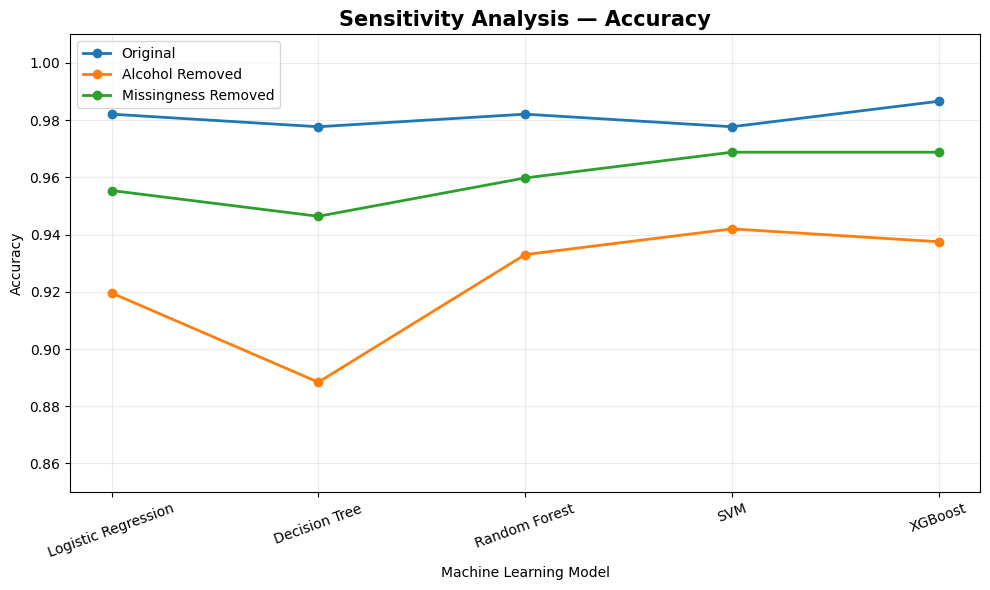

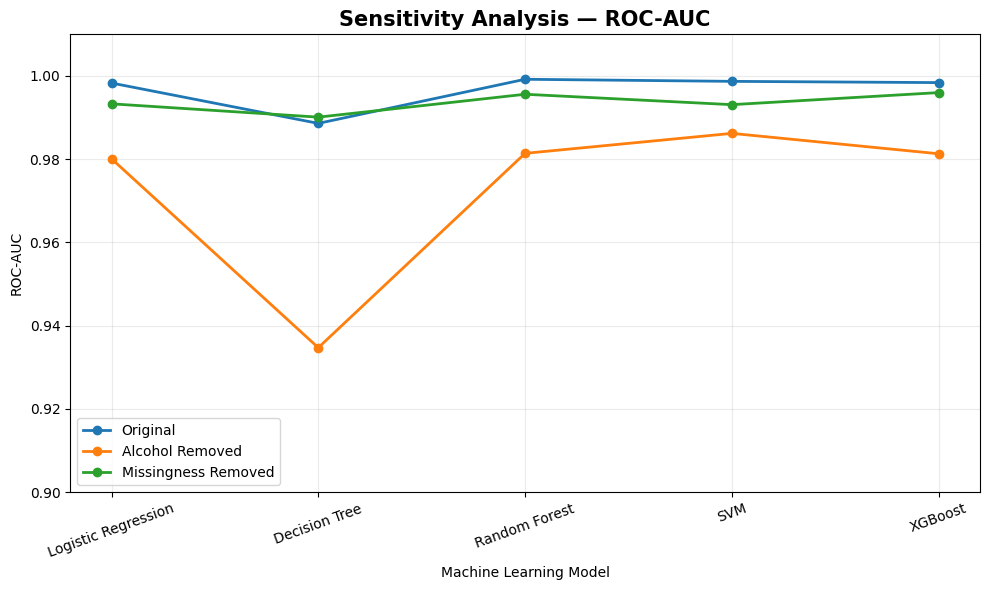

In [ ]:
# ============================================================
# STEP 15E — SENSITIVITY ANALYSIS PLOT
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt


# ============================================================
# DATA
# ============================================================

results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],

    "Original_Accuracy": [
        0.9821, 0.9777, 0.9821, 0.9777, 0.9866
    ],

    "Alcohol_Removed_Accuracy": [
        0.9196, 0.8884, 0.9330, 0.9420, 0.9375
    ],

    "Missingness_Removed_Accuracy": [
        0.9554, 0.9464, 0.9598, 0.9688, 0.9688
    ],

    "Original_ROC_AUC": [
        0.9983, 0.9886, 0.9992, 0.9987, 0.9984
    ],

    "Alcohol_Removed_ROC_AUC": [
        0.9801, 0.9347, 0.9814, 0.9862, 0.9813
    ],

    "Missingness_Removed_ROC_AUC": [
        0.9933, 0.9901, 0.9956, 0.9931, 0.9960
    ]
})


# ============================================================
# ACCURACY PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    results["Model"],
    results["Original_Accuracy"],
    marker="o",
    linewidth=2,
    label="Original"
)

plt.plot(
    results["Model"],
    results["Alcohol_Removed_Accuracy"],
    marker="o",
    linewidth=2,
    label="Alcohol Removed"
)

plt.plot(
    results["Model"],
    results["Missingness_Removed_Accuracy"],
    marker="o",
    linewidth=2,
    label="Missingness Removed"
)

plt.title(
    "Sensitivity Analysis — Accuracy",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Accuracy")

plt.ylim(0.85, 1.01)

plt.xticks(rotation=20)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "sensitivity_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ============================================================
# ROC-AUC PLOT
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    results["Model"],
    results["Original_ROC_AUC"],
    marker="o",
    linewidth=2,
    label="Original"
)

plt.plot(
    results["Model"],
    results["Alcohol_Removed_ROC_AUC"],
    marker="o",
    linewidth=2,
    label="Alcohol Removed"
)

plt.plot(
    results["Model"],
    results["Missingness_Removed_ROC_AUC"],
    marker="o",
    linewidth=2,
    label="Missingness Removed"
)

plt.title(
    "Sensitivity Analysis — ROC-AUC",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("ROC-AUC")

plt.ylim(0.90, 1.01)

plt.xticks(rotation=20)

plt.legend()

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "sensitivity_roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
# ============================================================
# STEP 16 — FINAL MODEL PERFORMANCE TABLE
# ============================================================

import pandas as pd

final_results = pd.DataFrame({

    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "XGBoost"
    ],

    "CV Accuracy": [
        "0.9855 ± 0.0109",
        "0.9654 ± 0.0178",
        "0.9810 ± 0.0104",
        "0.9732 ± 0.0096",
        "0.9832 ± 0.0106"
    ],

    "Test Accuracy": [
        0.9821,
        0.9777,
        0.9821,
        0.9777,
        0.9866
    ],

    "Test Precision": [
        1.0000,
        0.9732,
        0.9735,
        0.9818,
        0.9737
    ],

    "Test Recall": [
        0.9640,
        0.9820,
        0.9910,
        0.9730,
        1.0000
    ],

    "Test Specificity": [
        1.0000,
        0.9735,
        0.9735,
        0.9823,
        0.9735
    ],

    "Test F1": [
        0.9817,
        0.9776,
        0.9821,
        0.9774,
        0.9867
    ],

    "Test ROC-AUC": [
        0.9983,
        0.9886,
        0.9992,
        0.9987,
        0.9984
    ],

    "Test AP": [
        0.9984,
        0.9773,
        0.9992,
        0.9987,
        0.9983
    ],

    "Brier Score": [
        0.0147,
        0.0169,
        0.0193,
        0.0143,
        0.0122
    ]
})


print("=" * 120)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("=" * 120)

display(
    final_results.style.format({
        "Test Accuracy": "{:.4f}",
        "Test Precision": "{:.4f}",
        "Test Recall": "{:.4f}",
        "Test Specificity": "{:.4f}",
        "Test F1": "{:.4f}",
        "Test ROC-AUC": "{:.4f}",
        "Test AP": "{:.4f}",
        "Brier Score": "{:.4f}"
    })
)

FINAL MODEL PERFORMANCE SUMMARY


,Model,CV Accuracy,Test Accuracy,Test Precision,Test Recall,Test Specificity,Test F1,Test ROC-AUC,Test AP,Brier Score
0,Logistic Regression,0.9855 ± 0.0109,0.9821,1.0000,0.9640,1.0000,0.9817,0.9983,0.9984,0.0147
1,Decision Tree,0.9654 ± 0.0178,0.9777,0.9732,0.9820,0.9735,0.9776,0.9886,0.9773,0.0169
2,Random Forest,0.9810 ± 0.0104,0.9821,0.9735,0.9910,0.9735,0.9821,0.9992,0.9992,0.0193
3,SVM,0.9732 ± 0.0096,0.9777,0.9818,0.9730,0.9823,0.9774,0.9987,0.9987,0.0143
4,XGBoost,0.9832 ± 0.0106,0.9866,0.9737,1.0000,0.9735,0.9867,0.9984,0.9983,0.0122
